# 모델 선택 실험: 수명을 나눌 만한 기준이 보이나?

지금 확인할 것은 **회귀로 사이클 수를 예측할지, 분류로 수명 그룹을 맞힐지 정할 근거**입니다. 아래 1~4번 구간에서 수명 그룹의 경계와 머신러닝 후보의 성능을 함께 확인합니다. 이후의 꺾임·전압 분석은 참고 자료로 남깁니다.

모델 입력 후보는 처음 100사이클 안의 `log10_dqv_var`입니다. 같은 전압에서 `사이클 100의 용량 − 사이클 10의 용량`을 구하고, 전압별 차이의 분산에 log10을 적용합니다. 나중에 찾은 꺾임이나 마지막 용량은 입력에 쓰지 않습니다.

| 선택 | 맞힐 값 | 이번에 확인할 점 |
|---|---|---|
| 회귀 | 수명이 몇 사이클인지 | 초기 값과 수명이 연속적으로 연결되는가? |
| 분류: 500 미만 / 나머지 | 수명이 짧은 셀인가? | 짧은 셀이 배치별로 충분히 있는가? |
| 분류: 1000 초과 / 나머지 | 수명이 긴 셀인가? | 중간 수명까지 포함해 나눌 수 있는가? |
| 분류: 500 미만 / 1000 초과 | 확실히 짧은 셀과 긴 셀 구분 | 가운데 셀을 뺐을 때 구분되는가? |

500·1000은 과제에서 사용한 **수명 그룹의 기준**입니다. 아래에서 찾는 `log10_dqv_var`의 경계는 그 그룹을 예측하기 위한 **입력값의 기준**입니다. 이 둘을 구분해서 봅니다.

## 최종 test와 모델 선택 데이터의 구분

Batch1~3의 수명 관계와 모델 점수를 보고 입력 변수와 후보를 골랐습니다. 이 중 한 배치를 나중에 최종 test로 다시 쓰면 **모델 선택 단계에서 test 정보가 들어간 것**입니다. 학습 코드가 그 배치에서 fit하지 않았어도, 사람이 그 배치의 결과를 보고 모델을 선택하면 최종 평가의 독립성이 깨집니다. [scikit-learn 설명](https://scikit-learn.org/stable/modules/cross_validation.html)

현재 Batch1~3은 개발·탐색·후보 검증에 사용한 데이터입니다. Random Forest는 여기에서 나온 잠정 후보이고, MAE 166사이클은 최종 test 성능이 아닙니다. 이미 본 배치에 test라는 이름을 새로 붙여도 이를 되돌릴 수 없습니다.

나중에 평가할 데이터가 **지금까지 구조 외에 분포·수명 관계·성능을 전혀 살펴보지 않은 새 배치**라면, 모델과 입력 변수·전처리·설정을 먼저 고정하고 그 배치에서 한 번 평가할 수 있습니다. 새 배치 없이 진행할 때는 현재 결과를 탐색/검증 결과로 보고하고, 독립 최종 test가 없다는 한계를 명시합니다.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

MODEL_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_DATA = MODEL_ROOT / "data" / "processed"
MODEL_BATCHES = ["batch1", "batch2", "batch3"]
MODEL_SEED = 42
# 그림에서 점을 조금 흩어 놓는 위치도 다시 실행하면 같게 합니다.
np.random.seed(MODEL_SEED)
model_frames = []
for batch_name in MODEL_BATCHES:
    frame = pd.read_csv(MODEL_DATA / f"{batch_name}_cells.csv").assign(batch=batch_name)
    variances = []
    with np.load(MODEL_DATA / f"{batch_name}_cycle_profiles.npz", allow_pickle=False) as archive:
        for cell_id in frame["cell_id"]:
            cycles = archive[f"cell_{cell_id}_cycle"]
            indices = [np.flatnonzero(cycles == cycle) for cycle in [10, 100]]
            assert all(len(index) == 1 for index in indices), "사이클 10과 100을 확인하세요."
            q = archive[f"cell_{cell_id}_qdlin"]
            assert q.shape == (len(cycles), 1000)
            delta = q[indices[1][0]] - q[indices[0][0]]
            assert np.isfinite(delta).all()
            variance = np.var(delta)
            variances.append(np.log10(variance) if variance > 0 else np.nan)
            del q
    frame["log10_dqv_var"] = variances
    model_frames.append(frame)
model_cells = pd.concat(model_frames, ignore_index=True)
assert not model_cells.duplicated(["batch", "cell_id"]).any()
model_data = model_cells.dropna(subset=["cycle_life", "log10_dqv_var"]).copy()
assert model_data["cycle_life"].gt(0).all()
model_data["life_group"] = np.select(
    [model_data["cycle_life"] < 500, model_data["cycle_life"] > 1000],
    ["Short (<500)", "Long (>1000)"], default="Middle (500-1000)"
)
MODEL_GROUPS = ["Short (<500)", "Middle (500-1000)", "Long (>1000)"]
display(pd.crosstab(model_data["batch"], model_data["life_group"]).reindex(columns=MODEL_GROUPS, fill_value=0))
display(model_data.groupby("life_group")["log10_dqv_var"].agg(["count", "min", "median", "max"]).reindex(MODEL_GROUPS).round(4))
print(f"수명과 초기 값이 모두 있는 셀: {len(model_data)} / 전체 {len(model_cells)}")

life_group,Short (<500),Middle (500-1000),Long (>1000)
batch,,,
batch1,0,36,10
batch2,28,8,3
batch3,0,21,23


,count,min,median,max
life_group,,,,
Short (<500),28,-3.7073,-3.4461,-3.0859
Middle (500-1000),65,-4.3645,-3.9522,-3.3503
Long (>1000),36,-5.0989,-4.3112,-3.9387


수명과 초기 값이 모두 있는 셀: 129 / 전체 139


## 1. 짧은 수명과 긴 수명이 입력값에서도 구분되는가?

중간 수명 셀까지 포함한 그림과, 양쪽 수명만 고른 그림을 구분해서 봅니다. 중간을 뺀 뒤 잘 나뉜다는 결과를 전체 셀의 분류 성능으로 해석하지 않습니다.

회귀 관점에서는 값이 바뀔 때 수명도 차례로 달라지는지 봅니다. 분류 관점에서는 두 그룹의 입력값이 겹치는지 봅니다.

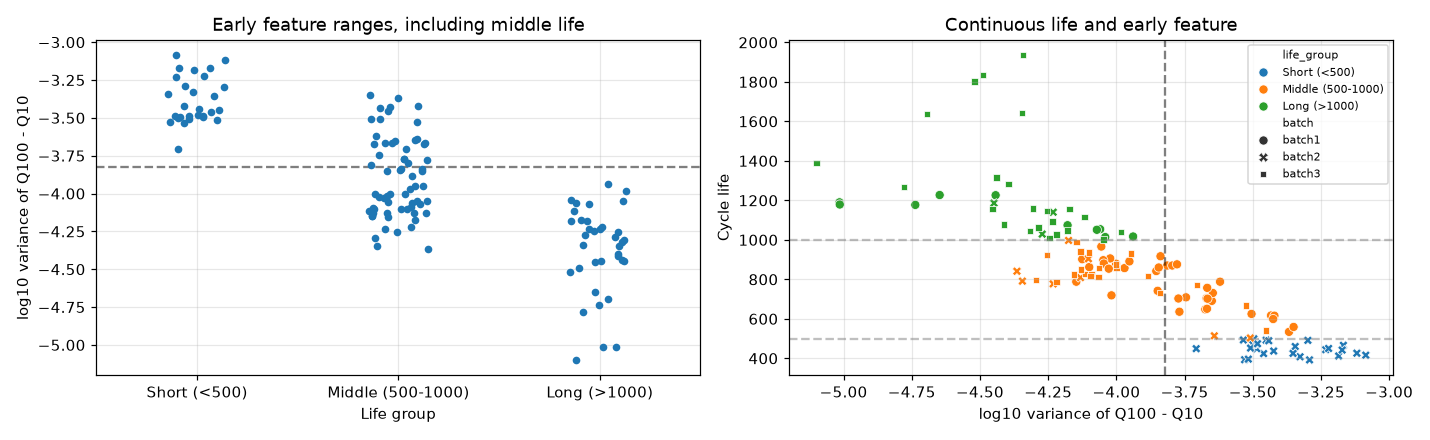

양쪽 그룹 64개, 이번 비교에서 빠지는 중간 수명 65개
현재 양쪽 그룹은 log10_dqv_var 약 -3.823를 사이에 두고 겹치지 않습니다.
전체 셀의 Pearson: -0.851


In [2]:
# 가운데 수명 셀을 빼면 두 그룹의 입력값 범위 사이에 빈 구간이 있는지 확인합니다.
short_values = model_data.loc[model_data["cycle_life"] < 500, "log10_dqv_var"]
long_values = model_data.loc[model_data["cycle_life"] > 1000, "log10_dqv_var"]
assert len(short_values) and len(long_values)
separation_gap = short_values.min() - long_values.max()
extreme_cut = (short_values.min() + long_values.max()) / 2 if separation_gap > 0 else np.nan
extremes = model_data.loc[model_data["life_group"].ne("Middle (500-1000)")].copy()
print(f"양쪽 그룹 {len(extremes)}개, 이번 비교에서 빠지는 중간 수명 {len(model_data) - len(extremes)}개")
if pd.notna(extreme_cut):
    print(f"현재 양쪽 그룹은 log10_dqv_var 약 {extreme_cut:.3f}를 사이에 두고 겹치지 않습니다.")
else:
    print("중간 수명을 빼도 두 그룹의 초기 값이 겹칩니다.")
print(f"전체 셀의 Pearson: {model_data['log10_dqv_var'].corr(model_data['cycle_life']):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.stripplot(data=model_data, x="life_group", y="log10_dqv_var", order=MODEL_GROUPS, jitter=0.15, ax=axes[0])
sns.scatterplot(data=model_data, x="log10_dqv_var", y="cycle_life", hue="life_group", hue_order=MODEL_GROUPS, style="batch", ax=axes[1])
axes[0].set(title="Early feature ranges, including middle life", xlabel="Life group", ylabel="log10 variance of Q100 - Q10")
axes[1].set(title="Continuous life and early feature", xlabel="log10 variance of Q100 - Q10", ylabel="Cycle life")
for boundary in [500, 1000]:
    axes[1].axhline(boundary, color="gray", linestyle="--", alpha=0.5)
if pd.notna(extreme_cut):
    axes[0].axhline(extreme_cut, color="black", linestyle="--", alpha=0.5)
    axes[1].axvline(extreme_cut, color="black", linestyle="--", alpha=0.5)
for ax in axes:
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 2. 전체 셀을 1000사이클 기준으로 나누면 다른 배치에도 맞는가?

`1000 초과 / 1000 이하`라면 중간 수명도 포함합니다. 초기 값 하나에 경계선을 그어 이 그룹을 나눠 봅니다. 정식 분류모델을 만드는 단계는 아닙니다.

경계선은 **두 배치에서 고르고, 남은 배치에 적용**합니다. 평가할 배치의 수명을 보고 경계를 조정하지 않습니다. 각 그룹을 맞힌 비율을 따로 보고, 두 비율의 평균도 표시합니다. 셀 수가 많은 그룹만 맞혀 높은 점수를 얻는 일을 피하려는 확인입니다.

In [3]:
def choose_long_life_cut(values, labels):
    """긴 수명은 초기 분산이 작다는 방향으로 경계 하나를 고릅니다."""
    if labels.nunique() < 2:
        return None
    x = values.to_numpy()
    y = labels.to_numpy(dtype=bool)
    ordered = np.unique(x)
    candidates = np.r_[ordered[0] - 1e-6, (ordered[:-1] + ordered[1:]) / 2, ordered[-1] + 1e-6]
    scores = [0.5 * ((x[y] <= cut).mean() + (x[~y] > cut).mean()) for cut in candidates]
    return float(candidates[np.argmax(scores)])

# 두 값이 확실히 나뉘는 작은 예시로 경계 찾기 방향을 확인합니다.
check_cut = choose_long_life_cut(pd.Series([-5.0, -4.8, -3.5, -3.3]), pd.Series([True, True, False, False]))
assert -4.8 < check_cut < -3.5
assert choose_long_life_cut(pd.Series([-5.0, -4.8]), pd.Series([True, True])) is None

boundary_rows = []
for held_out in MODEL_BATCHES:
    train = model_data.loc[model_data["batch"].ne(held_out)]
    test = model_data.loc[model_data["batch"].eq(held_out)]
    cut = choose_long_life_cut(train["log10_dqv_var"], train["cycle_life"] > 1000)
    assert cut is not None
    actual_long = test["cycle_life"] > 1000
    predicted_long = test["log10_dqv_var"] <= cut
    long_correct = predicted_long[actual_long].mean()
    other_correct = (~predicted_long[~actual_long]).mean()
    boundary_rows.append({"validation_batch": held_out, "cut_from_other_batches": cut,
        "n_long": actual_long.sum(), "n_other": (~actual_long).sum(),
        "long_correct_percent": long_correct * 100,
        "other_correct_percent": other_correct * 100,
        "mean_of_two_percent": (long_correct + other_correct) / 2 * 100})
boundary_check = pd.DataFrame(boundary_rows)
display(boundary_check.round(2))

# 500 미만 분류는 단수명 셀이 특정 배치에만 있는지 먼저 확인합니다.
short_counts = model_data.assign(short=model_data["cycle_life"] < 500).groupby("batch")["short"].agg(["sum", "count"])
display(short_counts.rename(columns={"sum": "short_cells", "count": "known_cells"}))
if short_counts["sum"].gt(0).sum() == 1:
    print("단수명 셀이 한 배치에만 있습니다. 그 배치를 평가용으로 빼면 학습용에 단수명 예시가 없어집니다.")

,validation_batch,cut_from_other_batches,n_long,n_other,long_correct_percent,other_correct_percent,mean_of_two_percent
0,batch1,-4.16,10,36,60.00,100.00,80.00
1,batch2,-4.16,3,36,100.00,88.89,94.44
2,batch3,-4.03,23,21,95.65,38.10,66.87


,short_cells,known_cells
batch,,
batch1,0,46
batch2,28,39
batch3,0,44


단수명 셀이 한 배치에만 있습니다. 그 배치를 평가용으로 빼면 학습용에 단수명 예시가 없어집니다.


## 3. 같은 초기 변수로 머신러닝 후보 비교하기

지금은 `log10_dqv_var` **하나만** 입력으로 넣습니다. 앞에서 발견한 수명 관계가 실제 예측에도 도움이 되는지 확인하려는 비교입니다. 변수 추가와 세부 설정 조정은 이 비교 이후에 진행합니다.

| 문제 | 후보 | 쓰는 이유 |
|---|---|---|
| 회귀 | Ridge | 직선 관계를 먼저 확인하는 간단한 기준 모델 |
| 회귀 | Random Forest | 직선 하나로 설명하기 어려운 관계도 나눠서 학습 |
| 분류 | Logistic Regression | 입력값에 따라 장수명일 확률이 달라지는지 확인 |
| 분류 | Random Forest | 여러 결정 트리의 판단을 모아 수명 그룹을 예측 |

**Random Forest는 이미 앙상블입니다.** 여러 트리를 합치는 방식입니다. XGBoost 같은 부스팅도 후보가 될 수 있지만, 이번에는 위 후보로 기준을 먼저 잡습니다. 부스팅이 부적합하다고 판단해서 제외한 것은 아닙니다. 모델 설명은 [scikit-learn 선형 모델 문서](https://scikit-learn.org/stable/modules/linear_model.html)와 [Random Forest 문서](https://scikit-learn.org/stable/modules/ensemble.html#forest)를 참고합니다.

- 다른 두 배치로 학습하고 남은 배치로 평가합니다. 같은 셀의 사이클을 학습/평가에 나누지 않습니다.
- 회귀는 `log10(cycle_life)`를 학습한 뒤 사이클 수로 되돌립니다. 오차는 원래 사이클 단위로 계산합니다.
- 분류는 모든 셀을 포함해 `1000 초과=1 / 1000 이하=0`으로 둡니다. 두 그룹을 맞힌 비율의 평균을 주 지표로 봅니다.
- 입력값의 표준화는 학습용 셀에서만 계산합니다. 배치 번호와 나중에 확인한 꺾임은 입력에 넣지 않습니다.
- 설정은 평가 전에 고정합니다. 가장 짧은 수명도 100사이클보다 길어, 이번 비교에서는 모든 셀이 초기 관측 구간을 채웁니다.

단순 기준도 함께 표시합니다. 회귀 기준은 학습 수명의 중앙값만 예측하고, 분류 기준은 학습에서 더 많은 그룹만 예측합니다.

이 배치별 비교에서는 앞선 배치를 평가할 때 뒤 배치로 학습하기도 합니다. 배치가 달라지는 영향은 볼 수 있지만, 앞으로 들어올 배치의 예측 성능은 아래 날짜 순서 검증으로 따로 확인합니다. 세 배치 모두 이미 EDA와 후보 비교에 사용해, 별도로 남겨 둔 최종 test는 없습니다.

In [4]:
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import mean_absolute_error, balanced_accuracy_score, recall_score, roc_auc_score

# 같은 입력을 써야 모델의 차이를 비교할 수 있습니다. 배치는 평가 구분에만 씁니다.
MODEL_FEATURES = ["log10_dqv_var"]
model_x = model_data[MODEL_FEATURES]
assert np.isfinite(model_x.to_numpy()).all()
assert model_data["cycle_life"].gt(100).all()
ml_regressors = {
    "Median baseline": DummyRegressor(strategy="median"),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0, solver="cholesky")),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=4, min_samples_leaf=3, random_state=MODEL_SEED, n_jobs=1
    ),
}
ml_classifiers = {
    "Majority baseline": DummyClassifier(strategy="most_frequent", random_state=MODEL_SEED),
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=MODEL_SEED)
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=4, min_samples_leaf=3,
        class_weight="balanced", random_state=MODEL_SEED, n_jobs=1
    ),
}
# 트리를 얕게 두고 말단에 최소 3개 셀을 남겨, 적은 표본을 너무 잘게 나누지 않습니다.
# ponytail: 입력 하나와 고정 설정으로 첫 비교만 합니다. 변수를 늘린 뒤 튜닝은 별도 검증에서 진행합니다.
regression_rows, classification_rows, regression_predictions = [], [], []
for held_out in MODEL_BATCHES:
    train_mask = model_data["batch"].ne(held_out)
    test_mask = ~train_mask
    assert not set(model_data.loc[train_mask, "batch"]) & set(model_data.loc[test_mask, "batch"])
    x_train, x_test = model_x.loc[train_mask], model_x.loc[test_mask]
    life_train = model_data.loc[train_mask, "cycle_life"]
    life_test = model_data.loc[test_mask, "cycle_life"]

    for name, candidate in ml_regressors.items():
        estimator = clone(candidate).fit(x_train, np.log10(life_train))
        predicted_life = np.power(10.0, estimator.predict(x_test))
        assert np.isfinite(predicted_life).all() and (predicted_life > 0).all()
        regression_rows.append({"model": name, "validation_batch": held_out, "n": len(life_test),
            "MAE_cycles": mean_absolute_error(life_test, predicted_life)})
        regression_predictions.append(model_data.loc[test_mask, ["batch", "cell_id", "cycle_life"]].assign(
            model=name, predicted_life=predicted_life))

    # 수가 적은 장수명 그룹도 학습에 반영하도록 두 분류모델에 class_weight를 적용합니다.
    long_train, long_test = life_train.gt(1000).astype(int), life_test.gt(1000).astype(int)
    assert long_train.nunique() == long_test.nunique() == 2
    for name, candidate in ml_classifiers.items():
        estimator = clone(candidate).fit(x_train, long_train)
        predicted_group = estimator.predict(x_test)
        long_probability = estimator.predict_proba(x_test)[:, 1]
        classification_rows.append({"model": name, "validation_batch": held_out, "n": len(long_test),
            "long_correct_percent": recall_score(long_test, predicted_group) * 100,
            "other_correct_percent": recall_score(long_test, predicted_group, pos_label=0) * 100,
            "group_mean_percent": balanced_accuracy_score(long_test, predicted_group) * 100,
            "AUC": roc_auc_score(long_test, long_probability)})

regression_scores = pd.DataFrame(regression_rows)
classification_scores = pd.DataFrame(classification_rows)
regression_oof = pd.concat(regression_predictions, ignore_index=True)
assert not regression_oof.duplicated(["model", "batch", "cell_id"]).any()
assert regression_oof.groupby("model").size().eq(len(model_data)).all()
print("회귀: 평균 절대 오차(MAE), 낮을수록 좋습니다.")
display(regression_scores.round(1))
print("분류: 두 그룹의 정답률을 각각 확인합니다. AUC는 장수명 셀에 더 높은 확률을 주는 정도입니다.")
display(classification_scores.round(3))

# 배치 평균은 각 배치를 같은 비중으로 봅니다. 전체 셀 오차는 셀 수를 반영합니다.
regression_summary = regression_scores.groupby("model").agg(
    batch_mean_MAE=("MAE_cycles", "mean"), worst_batch_MAE=("MAE_cycles", "max"))
regression_summary["all_cells_MAE"] = regression_oof.assign(
    absolute_error=(regression_oof["predicted_life"] - regression_oof["cycle_life"]).abs()
).groupby("model")["absolute_error"].mean()
classification_summary = classification_scores.groupby("model").agg(
    batch_mean_group_percent=("group_mean_percent", "mean"),
    worst_batch_group_percent=("group_mean_percent", "min"), mean_AUC=("AUC", "mean"))
display(regression_summary.round(1))
display(classification_summary.round(3))

,model,validation_batch,n,MAE_cycles
0,Median baseline,batch1,46,150.4
1,Ridge,batch1,46,144.8
2,Random Forest,batch1,46,117.0
3,Median baseline,batch2,39,357.8
4,Ridge,batch2,39,158.5
5,Random Forest,batch2,39,164.4
6,Median baseline,batch3,44,364.8
7,Ridge,batch3,44,172.0
8,Random Forest,batch3,44,178.4


,model,validation_batch,n,long_correct_percent,other_correct_percent,group_mean_percent,AUC
0,Majority baseline,batch1,46,0.000,100.000,50.000,0.500
1,Logistic Regression,batch1,46,60.000,91.667,75.833,0.933
2,Random Forest,batch1,46,70.000,80.556,75.278,0.918
3,Majority baseline,batch2,39,0.000,100.000,50.000,0.500
4,Logistic Regression,batch2,39,100.000,86.111,93.056,0.954
5,Random Forest,batch2,39,100.000,88.889,94.444,0.921
6,Majority baseline,batch3,44,0.000,100.000,50.000,0.500
7,Logistic Regression,batch3,44,95.652,38.095,66.874,0.896
8,Random Forest,batch3,44,95.652,71.429,83.540,0.872


,batch_mean_MAE,worst_batch_MAE,all_cells_MAE
model,,,
Median baseline,291.0,364.8,286.2
Random Forest,153.3,178.4,152.3
Ridge,158.4,172.0,158.2


,batch_mean_group_percent,worst_batch_group_percent,mean_AUC
model,,,
Logistic Regression,78.588,66.874,0.928
Majority baseline,50.000,50.000,0.500
Random Forest,84.421,75.278,0.904


회귀: 평균 절대 오차(MAE), 낮을수록 좋습니다.
분류: 두 그룹의 정답률을 각각 확인합니다. AUC는 장수명 셀에 더 높은 확률을 주는 정도입니다.


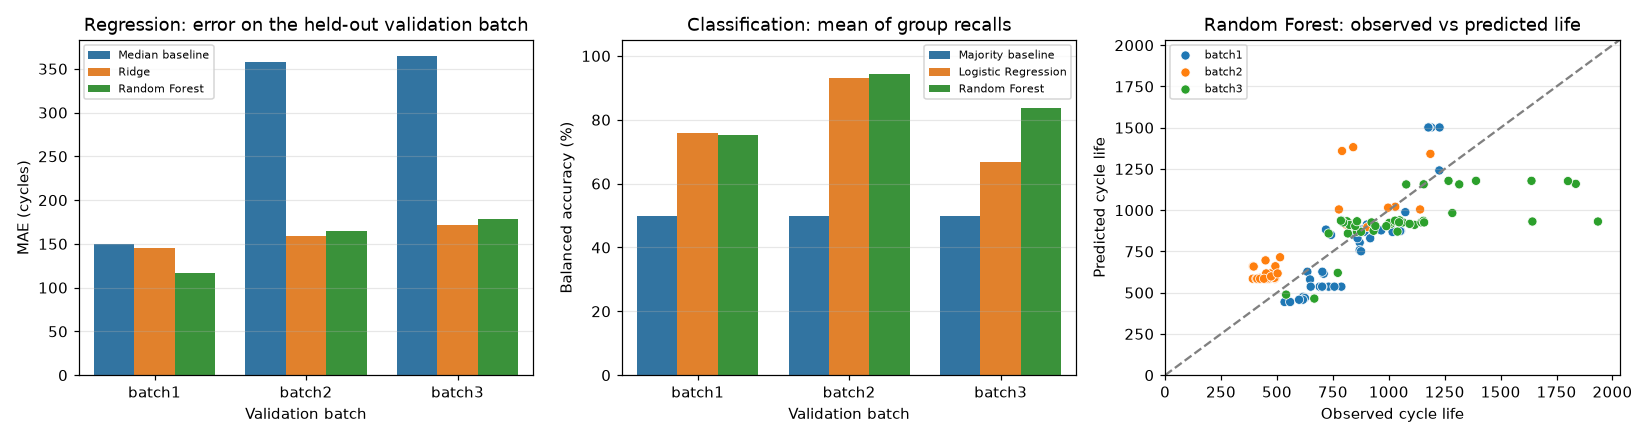

In [5]:
# 모든 점은 해당 셀의 배치를 학습에서 뺀 모델의 예측입니다. 학습 셀을 다시 맞힌 그림이 아닙니다.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=regression_scores, x="validation_batch", y="MAE_cycles", hue="model", ax=axes[0])
sns.barplot(data=classification_scores, x="validation_batch", y="group_mean_percent", hue="model", ax=axes[1])
forest_predictions = regression_oof.loc[regression_oof["model"].eq("Random Forest")]
sns.scatterplot(data=forest_predictions, x="cycle_life", y="predicted_life", hue="batch", ax=axes[2])
limit = max(forest_predictions["cycle_life"].max(), forest_predictions["predicted_life"].max()) * 1.05
axes[2].plot([0, limit], [0, limit], color="gray", linestyle="--")
axes[2].set(xlim=(0, limit), ylim=(0, limit))
axes[0].set(title="Regression: error on the held-out validation batch", xlabel="Validation batch", ylabel="MAE (cycles)")
axes[1].set(title="Classification: mean of group recalls", xlabel="Validation batch", ylabel="Balanced accuracy (%)", ylim=(0, 105))
axes[2].set(title="Random Forest: observed vs predicted life", xlabel="Observed cycle life", ylabel="Predicted cycle life")
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 4. 과거 배치로 학습하고 다음 배치에서 검증하기

파일 이름만 보고 날짜 순서를 가정하지 않고 원본 `batch_date`를 읽습니다. 이 데이터의 순서는 Batch1(2017-05-12) → Batch2(2018-02-20) → Batch3(2018-04-12)입니다.

- Batch1로 학습 → Batch2에서 검증
- Batch1+2로 학습 → Batch3에서 검증

셀 하나를 한 행으로 두고, 초기 100사이클로 이후의 수명을 예측합니다. 같은 셀 안의 사이클 행을 섞는 무작위 분할은 하지 않습니다. 스케일러는 각 학습 구간의 Pipeline 안에서만 fit합니다. [scikit-learn의 누수 방지 설명](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)을 따릅니다.

이 역시 **추가 검증**입니다. 이미 본 Batch3를 새로 test라고 이름 붙여도 최종 test가 되지는 않습니다. 이 단계에서는 새 모델을 더 추가하거나 설정을 튜닝하지 않습니다.

학습 셀의 오차도 함께 표시합니다. 검증 오차가 훨씬 크면 과적합이나 배치 조건 차이가 있는지 봅니다. 두 원인은 이 차이 하나로 구분할 수 없습니다.

,batch,batch_date
0,batch1,2017-05-12
1,batch2,2018-02-20
2,batch3,2018-04-12


,model,train_batches,validation_batch,n,train_MAE_cycles,MAE_cycles,RMSE_cycles,R2,bias_cycles
0,Median baseline,batch1,batch2,39,145.935,342.166,365.805,-1.782,292.755
1,Ridge,batch1,batch2,39,77.805,172.687,182.641,0.307,151.310
2,Random Forest,batch1,batch2,39,44.249,152.732,165.886,0.428,146.858
3,Median baseline,batch1+batch2,batch3,44,210.294,364.750,471.984,-1.314,-355.659
4,Ridge,batch1+batch2,batch3,44,103.213,171.993,260.984,0.293,-122.729
5,Random Forest,batch1+batch2,batch3,44,52.530,178.410,272.169,0.231,-126.041


,n,all_cells_MAE
model,,
Median baseline,83,354.1
Random Forest,83,166.3
Ridge,83,172.3


n  MAE_cycles  bias_cycles
batch  model                                       
batch2 Median baseline   3       259.8       -259.8
       Random Forest     3        50.6        -25.8
       Ridge             3       116.7       -116.7
batch3 Median baseline  23       567.5       -567.5
       Random Forest    23       268.0       -261.2
       Ridge            23       263.8       -219.9

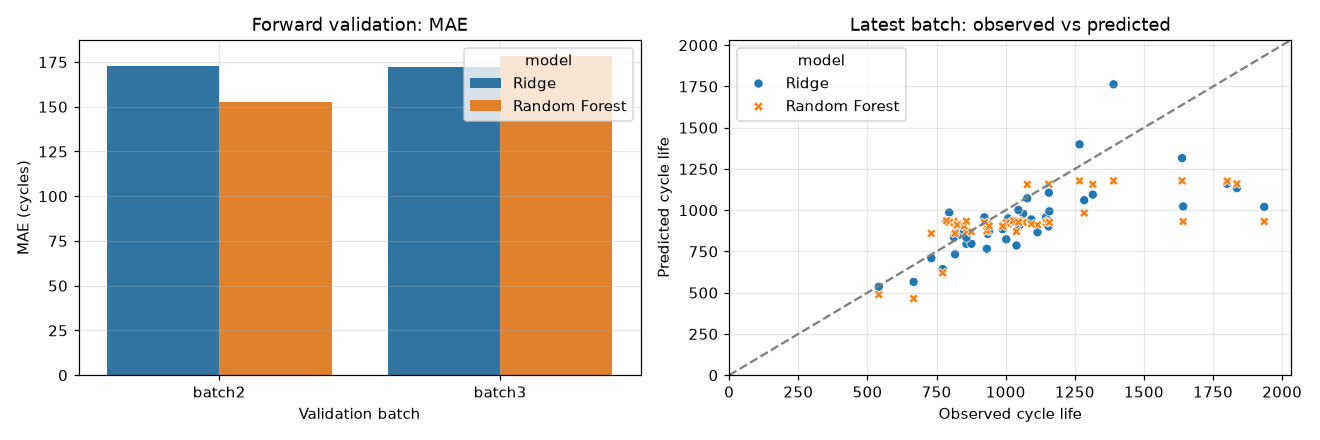

날짜 순서 검증: MAE/RMSE는 낮을수록 좋고, bias가 음수면 수명을 낮게 예측했습니다.
장수명 셀에서 오차가 더 큰지 따로 확인합니다.


In [6]:
import h5py
from sklearn.metrics import mean_squared_error, r2_score

model_date_rows = []
for batch_name in MODEL_BATCHES:
    with h5py.File(MODEL_ROOT / "data" / f"{batch_name.capitalize()}.mat", "r") as raw:
        batch_date = "".join(chr(int(value)) for value in raw["batch_date"][()].ravel())
    model_date_rows.append({"batch": batch_name, "batch_date": batch_date})
model_dates = pd.DataFrame(model_date_rows).sort_values("batch_date")
assert model_dates["batch_date"].nunique() == len(MODEL_BATCHES)
ordered_batches = model_dates["batch"].tolist()
display(model_dates)

chronological_rows, chronological_predictions = [], []
for position, validation_batch in enumerate(ordered_batches[1:], start=1):
    train_batches = ordered_batches[:position]
    train_mask = model_data["batch"].isin(train_batches)
    validation_mask = model_data["batch"].eq(validation_batch)
    assert not (train_mask & validation_mask).any()
    train_dates = model_dates.loc[model_dates["batch"].isin(train_batches), "batch_date"]
    validation_date = model_dates.loc[model_dates["batch"].eq(validation_batch), "batch_date"].iloc[0]
    assert train_dates.max() < validation_date
    actual = model_data.loc[validation_mask, "cycle_life"]
    for name, candidate in ml_regressors.items():
        estimator = clone(candidate).fit(
            model_x.loc[train_mask], np.log10(model_data.loc[train_mask, "cycle_life"]))
        predicted = np.power(10.0, estimator.predict(model_x.loc[validation_mask]))
        assert np.isfinite(predicted).all() and (predicted > 0).all()
        chronological_rows.append({"model": name, "train_batches": "+".join(train_batches),
            "validation_batch": validation_batch, "n": len(actual),
            "train_MAE_cycles": mean_absolute_error(model_data.loc[train_mask, "cycle_life"],
                np.power(10.0, estimator.predict(model_x.loc[train_mask]))),
            "MAE_cycles": mean_absolute_error(actual, predicted),
            "RMSE_cycles": np.sqrt(mean_squared_error(actual, predicted)),
            "R2": r2_score(actual, predicted), "bias_cycles": np.mean(predicted - actual)})
        chronological_predictions.append(model_data.loc[validation_mask, ["batch", "cell_id", "cycle_life"]].assign(
            model=name, predicted_life=predicted))
chronological_scores = pd.DataFrame(chronological_rows)
chronological_oof = pd.concat(chronological_predictions, ignore_index=True)
assert not chronological_oof.duplicated(["model", "batch", "cell_id"]).any()
assert chronological_oof.groupby("model").size().eq(model_data["batch"].isin(ordered_batches[1:]).sum()).all()
chronological_errors = chronological_oof.assign(
    absolute_error=(chronological_oof["predicted_life"] - chronological_oof["cycle_life"]).abs())
chronological_summary = chronological_errors.groupby("model").agg(
    n=("cell_id", "size"), all_cells_MAE=("absolute_error", "mean"))
long_life_errors = chronological_errors.loc[chronological_errors["cycle_life"] > 1000].assign(
    error=lambda frame: frame["predicted_life"] - frame["cycle_life"])
long_life_summary = long_life_errors.groupby(["batch", "model"]).agg(
    n=("cell_id", "size"), MAE_cycles=("absolute_error", "mean"), bias_cycles=("error", "mean"))
print("날짜 순서 검증: MAE/RMSE는 낮을수록 좋고, bias가 음수면 수명을 낮게 예측했습니다.")
display(chronological_scores.round(3))
display(chronological_summary.round(1))
print("장수명 셀에서 오차가 더 큰지 따로 확인합니다.")
display(long_life_summary.round(1))

# 전체 평균만 보면 가려지는 긴 수명의 과소 예측도 그림으로 확인합니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=chronological_scores.loc[chronological_scores["model"].ne("Median baseline")],
            x="validation_batch", y="MAE_cycles", hue="model", ax=axes[0])
latest_predictions = chronological_oof.loc[
    chronological_oof["batch"].eq(ordered_batches[-1]) & chronological_oof["model"].ne("Median baseline")]
sns.scatterplot(data=latest_predictions, x="cycle_life", y="predicted_life", hue="model", style="model", ax=axes[1])
limit = max(latest_predictions["cycle_life"].max(), latest_predictions["predicted_life"].max()) * 1.05
axes[1].plot([0, limit], [0, limit], "--", color="gray")
axes[1].set(xlim=(0, limit), ylim=(0, limit), title="Latest batch: observed vs predicted", xlabel="Observed cycle life", ylabel="Predicted cycle life")
axes[0].set(title="Forward validation: MAE", xlabel="Validation batch", ylabel="MAE (cycles)")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 잠정 후보: 초기 ΔQ(V) 분산을 사용하는 Random Forest 회귀

예측 시점은 **100사이클 관측 후**, 입력은 `log10_dqv_var` 하나, 출력은 예상 전체 `cycle_life`입니다. 학습할 때만 수명에 log10을 적용합니다. 예측한 수명을 사이클 수로 되돌려 평가합니다.

### 선정 이유

- 중간 수명 65개를 포함해 전체 수명 숫자를 예측하는 목적에 맞습니다.
- 초기 변화량과 수명의 음의 관계가 세 배치 안에서도 관찰됩니다. 최종 기록 길이와 나중에 생기는 꺾임은 입력에 쓰지 않습니다.
- 날짜 순서 검증에서 83개 셀의 MAE는 Random Forest 약 **166사이클**, Ridge 약 **172사이클**, 중앙값 기준 약 **354사이클**입니다. 개발 데이터의 평균 오차 기준으로 Random Forest를 잠정 후보로 둡니다.
- 설정을 200개 트리, 최대 깊이 4, 말단 최소 3개 셀, seed 42로 고정했습니다. 복잡한 튜닝을 시작하지 않아 첫 모델로 확인하기 쉽습니다.

### 이 모델을 선택하지 않을 이유

- Ridge보다 개선된 오차는 **약 6사이클**입니다. 표본과 검증 구간이 적어 우월성을 입증한 차이라고 볼 수 없습니다.
- 최신 Batch3에서는 Ridge가 MAE 약 **172**, Random Forest가 약 **178**로 더 좋았습니다.
- Batch3 장수명 23개에서 Random Forest는 수명을 평균 약 **261사이클 낮게** 예측했습니다. 학습 범위를 벗어난 장수명 예측이 주 목적이면 현재 Random Forest를 채택할 근거가 약해집니다. 기본 Random Forest 회귀는 학습한 말단 값들을 평균내므로 범위 밖으로 연장하는 데 제약이 있습니다. [공식 설명](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
- 현재 수명값의 정의가 일부 셀에서 불확실합니다. 새 배치의 최종 test와 운영 검증도 없어 지금 점수만으로 실제 성능을 확정하지 않습니다.

따라서 **현재 개발 데이터에 근거한 잠정 후보는 Random Forest 회귀**입니다. 최종 test의 독립성을 확보한 뒤 모델링 평가 설계를 확정합니다. 변수 추가·튜닝으로 선정 기준을 다시 바꿀 때는 별도 검증이 필요합니다. 확실한 장수명/단수명만 뽑는 분류는 중간 셀을 버리고, 단수명이 Batch2에만 있어 주 모델로 고르지 않습니다.

---
# 참고 자료: 전압 곡선과 꺾임 원인 살펴보기

아래는 기존 실험입니다. 모델 선택을 위한 위 비교를 본 뒤, 입력 변수의 의미나 셀별 변화가 궁금할 때 참고하세요.

# 실험: 용량이 갑자기 더 빠르게 줄어드는 이유 찾기

목표는 **용량 곡선이 꺾이는 시점에 무엇이 달라지는지** 확인하는 것입니다. 아래 순서로 살펴봅니다.

1. 같은 충전 방법에서 기본/`newstructure` 셀의 꺾임 시점 비교
2. 같은 셀의 꺾임 전후에서 전류·쉬는 시간·전압·내부저항·온도 비교
3. 초기에 달라진 Q(V)가 나중에 더 이른 꺾임과 연결되는지 확인

`newstructure` 표시는 다른 셀 그룹을 구분합니다. 현재 파일에는 셀 하나가 중간에 `newstructure`로 바뀐 시점을 알려 주는 기록이 없습니다. 따라서 **두 그룹의 차이**와 **각 셀의 꺾임 전후 변화**를 각각 확인합니다. 배터리 내부 구조가 바뀌었는지는 지금의 셀 정보만으로 알 수 없습니다.

먼저 Q–V 곡선의 모양을 확인합니다. `Qdlin`은 같은 전압에서 비교할 수 있도록 계산한 용량이고, `Vdlin`에는 짝이 되는 전압 1000개가 있습니다. 한 번 충전하고 방전하는 과정을 cycle(사이클)이라고 합니다. 아래 `BATCH`, `CELL_ID`, `CYCLES`를 바꿔 예시 셀을 고르세요.

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 보고 싶은 배치, 셀, 사이클 번호를 고릅니다.
BATCH = "batch1"
CELL_ID = 1
CYCLES = [10, 100]  # 저장된 번호라면 300처럼 뒤쪽 사이클도 추가할 수 있습니다.

# 프로젝트 폴더와 notebooks 폴더 중 어디서 실행해도 파일을 찾게 합니다.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "processed"

## 1. 보고 싶은 셀의 데이터 읽기

- `batchN_cells.csv`: 셀 번호, 충전 방법, 수명
- `batchN_cycle_profiles.npz`: 사이클 번호와 전압별 용량 `Qdlin`
- `batchN_vdlin.csv`: 용량값 1000개와 짝을 이루는 전압값

**파일의 첫 번째 행이 첫 번째 사이클이라는 뜻은 아닙니다.** Batch1은 실제 측정이 아닌 빈 데이터를 빼서 사이클 2부터 저장했습니다. 그래서 `cell_N_cycle`에 적힌 번호로 원하는 행을 찾습니다. 용량 파일이 크므로 선택한 셀의 데이터만 읽습니다.

In [8]:
assert BATCH in {"batch1", "batch2", "batch3"}, "BATCH는 batch1, batch2, batch3 중 선택하세요."
assert CYCLES and len(CYCLES) == len(set(CYCLES)), "CYCLES에 서로 다른 cycle 번호를 입력하세요."

metadata = pd.read_csv(DATA_DIR / f"{BATCH}_cells.csv")
selected_cell = metadata.loc[metadata["cell_id"].eq(CELL_ID)]
assert len(selected_cell) == 1, f"{BATCH}에 cell_id={CELL_ID}가 없습니다."
display(selected_cell)

voltage = pd.read_csv(DATA_DIR / f"{BATCH}_vdlin.csv")["Vdlin"].to_numpy()
with np.load(DATA_DIR / f"{BATCH}_cycle_profiles.npz", allow_pickle=False) as archive:
    cycle_numbers = archive[f"cell_{CELL_ID}_cycle"]
    qdlin = archive[f"cell_{CELL_ID}_qdlin"]

# 용량값 하나마다 짝이 되는 전압값이 있는지 확인합니다.
assert voltage.shape == (1000,) and np.isfinite(voltage).all()
assert np.all(np.diff(voltage) < 0), "전압축은 3.5 → 2.0 V 방향이어야 합니다."
assert np.all(np.diff(cycle_numbers) > 0), "저장된 cycle 번호가 중복되거나 순서가 맞지 않습니다."
assert qdlin.shape == (len(cycle_numbers), len(voltage)), "사이클 수 또는 전압값 수가 용량 데이터의 크기와 맞지 않습니다."

missing = sorted(set(CYCLES) - set(cycle_numbers))
assert not missing, (
    f"저장되지 않은 cycle: {missing}. 이 셀의 저장 범위: "
    f"{cycle_numbers[0]}~{cycle_numbers[-1]}. CYCLES를 수정하세요."
)
# 저장된 사이클 번호를 찾아 행을 고릅니다. 행 번호만으로 사이클을 판단하면 틀릴 수 있습니다.
row_indices = [np.flatnonzero(cycle_numbers == cycle)[0] for cycle in CYCLES]
q_curves = qdlin[row_indices]
assert np.isfinite(q_curves).all(), "선택한 용량에 비어 있거나 계산할 수 없는 값(NaN, inf)이 있습니다."
del qdlin  # 그래프에 쓸 사이클만 남겨 메모리를 줄입니다.

print(f"{BATCH} / cell {CELL_ID}: cycle {CYCLES}")
print(f"각 곡선: {len(voltage)} points, 전압 {voltage[0]:.1f} → {voltage[-1]:.1f} V")

,cell_id,channel,policy,cycle_life
0,1,47,3.6C(80%)-3.6C,1190


batch1 / cell 1: cycle [10, 100]
각 곡선: 1000 points, 전압 3.5 → 2.0 V


## 2. 같은 셀에서 사이클별 용량 비교하기

가로축은 전압 `Vdlin`, 세로축은 용량 `Qdlin`입니다. 전압이 3.5 V에서 2.0 V로 내려가는 순서로 그립니다. 사이클이 달라질 때 곡선이 어느 전압에서 벌어지는지 봅니다.

사이클 10과 100은 거의 겹칠 수 있습니다. 뒤쪽 사이클을 추가하면 처음과 나중의 차이도 볼 수 있습니다. 여기서는 파일에 저장된 값을 그대로 그립니다.

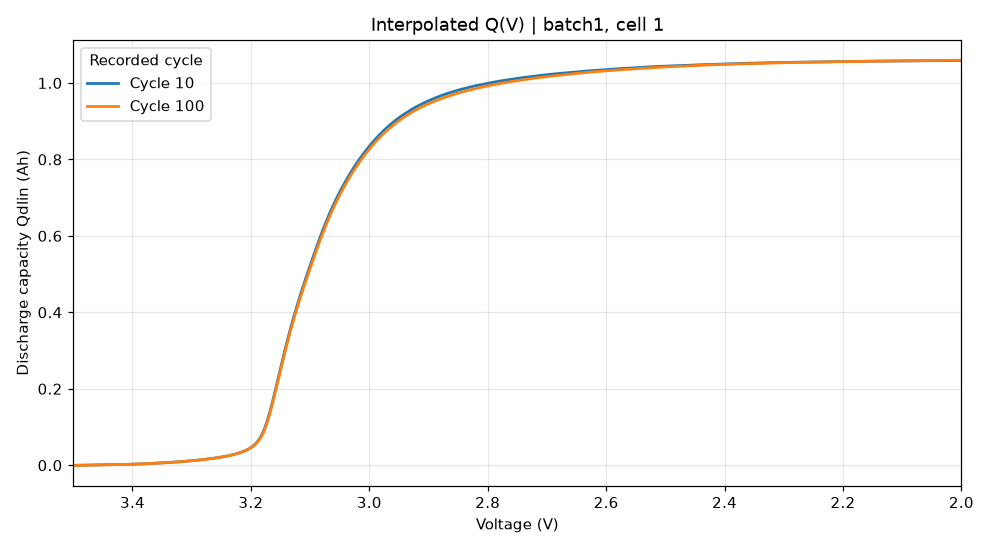

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for cycle, q_curve in zip(CYCLES, q_curves):
    ax.plot(voltage, q_curve, linewidth=1.8, label=f"Cycle {cycle}")

ax.set(
    title=f"Interpolated Q(V) | {BATCH}, cell {CELL_ID}",
    xlabel="Voltage (V)",
    ylabel="Discharge capacity Qdlin (Ah)",
    xlim=(voltage[0], voltage[-1]),
)
ax.grid(alpha=0.3)
ax.legend(title="Recorded cycle")
plt.tight_layout()
plt.show()

# 지적한 변화가 꺾임에 영향을 줄 수 있는가?

| 확인할 변화 | 꺾임과 연결될 수 있는 이유 | 이 노트북에서 볼 내용 |
|---|---|---|
| 기본/`newstructure`의 성능 차이 | 쉬는 시간·충전 후 머무는 시간 등 운전 조건이나 셀 차이가 손상이 쌓이는 속도를 바꿀 수 있음 | 같은 숫자 충전 방법에서 꺾임 시점 비교 |
| 특정 전압에서 Q가 가파르게 변함 | 전압이 평평한 구간에서는 작은 전압 이동도 큰 용량 차이로 보일 수 있음 | 꺾임 전후 V(Q)가 낮아지는지, Q(V)의 변화가 어디에 모이는지 확인 |
| 꺾임 부근의 내부저항·온도 변화 | 저항이 커지면 같은 전류로 방전해도 전압이 더 떨어지고, 방전을 더 빨리 끝낼 수 있음 | 꺾임 전후 저항과 같은 용량에서의 전압 비교 |
| 초기 `log10_dqv_var`와 수명 관계 | 초기 곡선 변화가 나중의 빠른 열화를 미리 보여주는 신호일 수 있음 | 초기 분산이 큰 셀에서 꺾임도 일찍 나타나는지 확인 |

분산이나 Q(V)의 가파른 모양은 확인할 **신호**입니다. 이것들이 배터리를 손상시키는 원인이라고 바로 해석하지 않습니다. 원인을 좁히려면 어떤 조건이 먼저 달라졌고, 그 뒤 어떤 변화가 나타났는지 봅니다.

저항 증가로 방전 종료 전압에 더 빨리 도달하는 것은 알려진 꺾임 설명 중 하나입니다. 이 데이터에서도 맞는지는 아래 측정값으로 확인합니다. [Attia et al. (2022), 저항과 꺾임](https://arxiv.org/html/2201.02891v1#S3.SS3)

## 3. 실제 배치 날짜와 충전 방법별 수명 확인하기

파일 안의 `batch_date`를 읽어 보니 현재 Batch2는 **2018-02-20**입니다. 원 논문 코드의 Batch2는 **2017-06-30**입니다. 따라서 논문 코드에 있는 셀 연결·제외 규칙을 우리 Batch2에도 쓸 수 있는지 먼저 확인해야 합니다. 아래 표에서 실제 날짜를 봅니다. [원 저자 LoadData.m](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/LoadData.m)

충전 방법의 숫자 부분은 `protocol`로 묶습니다. 뒤에 붙은 `newstructure`, `SLOWCYCLE`, `VarCharge`는 `variant`에 따로 남깁니다. 표의 **Base는 기본 그룹**, **Newstructure는 `newstructure` 표시가 붙은 그룹**입니다.

`newstructure`는 실험 설정 이름에 붙은 표시입니다. 현재 데이터에서는 같은 숫자 충전 방법이라도 쉬는 시간이 달랐습니다. 셀의 물리적 구조가 바뀌었다는 뜻으로 해석할 근거는 아직 없습니다.

수명이 비어 있는 셀도 데이터에는 남깁니다. 수명이 짧은 셀의 비율을 구할 때는 수명을 아는 셀만 셉니다.

,batch,batch_date
0,batch1,2017-05-12
1,batch2,2018-02-20
2,batch3,2018-04-12


n_cells  n_known  median_life  short_count  short_percent
batch  variant                                                                
batch1 Base               46       46        858.5            0           0.00
batch2 Base               30       30        451.0           28          93.33
       Newstructure        9        9        904.0            0           0.00
       Slowcycle           4        0          NaN            0            NaN
       VarCharge           4        0          NaN            0            NaN
batch3 Newstructure       46       44       1005.5            0           0.00

,protocol,batch,variant,n_cells,n_known,median_life
1,3.6C(80%)-3.6C,batch1,Base,3,3,1179.0
2,3.6C(80%)-3.6C,batch2,Slowcycle,1,0,NaN
3,3.6C(9%)-5C,batch2,Base,2,2,394.5
4,3.6C(9%)-5C,batch2,Slowcycle,1,0,NaN
9,4.8C(80%)-4.8C,batch1,Base,2,2,753.0
10,4.8C(80%)-4.8C,batch2,Base,5,5,492.0
11,4.8C(80%)-4.8C,batch2,Newstructure,3,3,809.0
12,4.8C(80%)-4.8C,batch2,Slowcycle,1,0,NaN
13,4.8C(80%)-4.8C,batch3,Newstructure,8,6,1640.0
16,5.2C(58%)-4C,batch2,Base,4,4,483.0


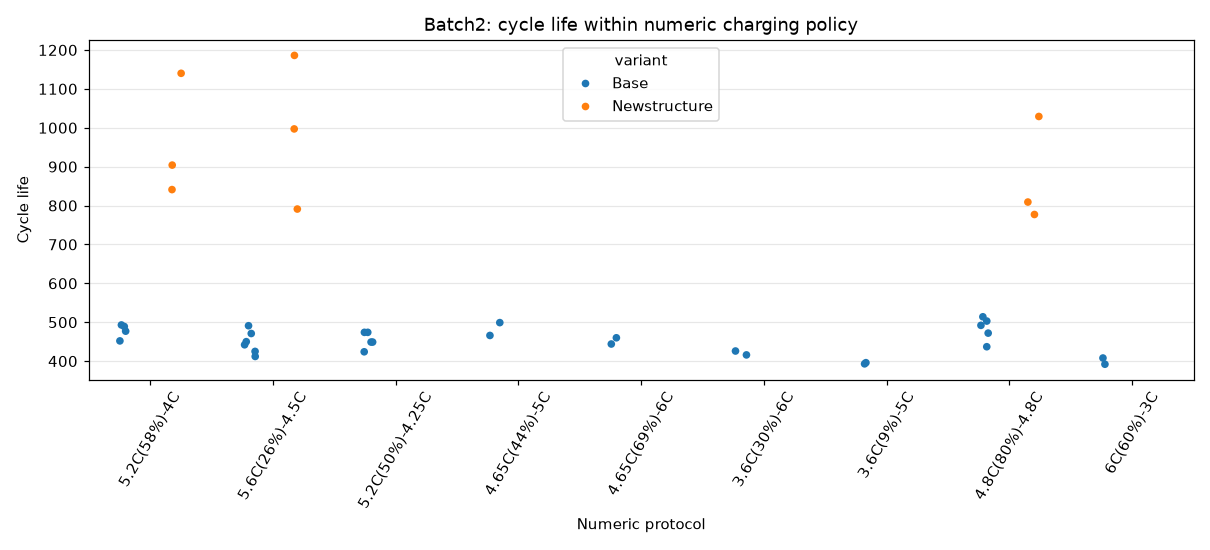

In [10]:
import h5py
import seaborn as sns

BATCHES = ["batch1", "batch2", "batch3"]
KEYS = ["batch", "cell_id"]
COLORS = dict(zip(BATCHES, sns.color_palette("colorblind", 3)))
frames, summary_frames, date_rows = [], [], []
for batch_name in BATCHES:
    raw_path = PROJECT_ROOT / "data" / f"{batch_name.capitalize()}.mat"
    with h5py.File(raw_path, "r") as f:
        batch_date = "".join(chr(int(value)) for value in f["batch_date"][()].ravel())
    date_rows.append({"batch": batch_name, "batch_date": batch_date})
    frames.append(pd.read_csv(DATA_DIR / f"{batch_name}_cells.csv").assign(batch=batch_name))
    summary_frames.append(pd.read_csv(DATA_DIR / f"{batch_name}_cycle_summary.csv").assign(batch=batch_name))
all_cells = pd.concat(frames, ignore_index=True)
all_summary = pd.concat(summary_frames, ignore_index=True)
assert not all_cells.duplicated(KEYS).any()
assert not all_summary.duplicated(KEYS + ["cycle"]).any()
display(pd.DataFrame(date_rows))

pattern = r"^(?P<first_c_rate>\d+(?:\.\d+)?)C\((?P<switch_soc>\d+(?:\.\d+)?)%\)-(?P<second_c_rate>\d+(?:\.\d+)?)C"
parsed = all_cells["policy"].str.extract(pattern).astype(float)
all_cells = pd.concat([all_cells, parsed], axis=1)
all_cells["variant"] = np.select(
    [all_cells["policy"].str.contains("SLOWCYCLE", na=False),
     all_cells["policy"].str.startswith("VarCharge", na=False),
     all_cells["policy"].str.contains("newstructure", na=False)],
    ["Slowcycle", "VarCharge", "Newstructure"], default="Base"
)
all_cells["protocol"] = all_cells["policy"]
regular = parsed.notna().all(axis=1)
all_cells.loc[regular, "protocol"] = all_cells.loc[regular].apply(
    lambda r: f"{r.first_c_rate:g}C({r.switch_soc:g}%)-{r.second_c_rate:g}C", axis=1
)
life_stats = all_cells.groupby(["batch", "variant"]).agg(
    n_cells=("cell_id", "size"), n_known=("cycle_life", "count"),
    median_life=("cycle_life", "median"),
    short_count=("cycle_life", lambda s: s.lt(500).sum())
)
life_stats["short_percent"] = life_stats["short_count"].div(life_stats["n_known"].replace(0, np.nan)).mul(100)
display(life_stats.round(2))

# 같은 숫자 충전 조건이 여러 배치나 그룹에 있으면 서로 비교합니다.
policy_life = all_cells.groupby(["protocol", "batch", "variant"]).agg(
    n_cells=("cell_id", "size"), n_known=("cycle_life", "count"), median_life=("cycle_life", "median")
).reset_index()
shared_protocols = policy_life.groupby("protocol").size().loc[lambda s: s > 1].index
shared = policy_life.loc[policy_life["protocol"].isin(shared_protocols)]
display(shared)

batch2 = all_cells.loc[all_cells["batch"].eq("batch2")].copy()
fig, ax = plt.subplots(figsize=(11, 5))
sns.stripplot(data=batch2.dropna(subset=["cycle_life"]), x="protocol", y="cycle_life", hue="variant", dodge=True, jitter=0.12, ax=ax)
ax.set(title="Batch2: cycle life within numeric charging policy", xlabel="Numeric protocol", ylabel="Cycle life")
ax.tick_params(axis="x", rotation=60)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 수명이 짧은 셀은 어디에 모여 있나? 수명값은 어떻게 정했나?

Batch2 기본 그룹은 **30개 중 28개(93.3%)가 500 사이클 미만**입니다. `newstructure` 그룹 9개는 모두 500 사이클 이상입니다. 수명이 짧은 셀이 기본 그룹에 많이 모여 있습니다.

같은 `5.2C(58%)-4C` 조건에서도 수명 중앙값은 기본 그룹 4개에서 483, `newstructure` 그룹 3개에서 904 사이클입니다. **중앙값**은 값을 크기순으로 놓았을 때 가운데에 있는 값입니다.

`cycle_life`가 정확히 무엇을 뜻하는지도 확인합니다. 제품의 기준 용량 1.1 Ah에서 80%는 0.88 Ah입니다. 그런데 Batch1 cell 1은 마지막에 기록된 용량이 약 1.03 Ah입니다. 이 셀의 수명값은 실제로 0.88 Ah에 도달한 시점인지, 측정을 끝낸 시점인지 더 확인해야 합니다. 원 저자도 이어서 측정한 셀과 측정이 끝나지 않은 셀을 따로 다룹니다. [원 저자 로딩 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/LoadData.m)

아래에서 `last5_q_median > 0.89`인 셀은 **마지막 용량을 더 살펴볼 셀**로 표시합니다. 마지막 5개 용량의 중앙값으로 한 번의 튀는 값에 영향을 덜 받게 합니다. 이 표시만으로 수명값을 바꾸지는 않습니다. 뒤에서는 마지막 용량이 기준 근처인 셀만 골라도 상관계수가 비슷한지 확인합니다.

In [11]:
# 마지막 값 하나가 튀어도 영향을 덜 받도록 마지막 5개 용량을 함께 봅니다.
tail = all_summary.sort_values(KEYS + ["cycle"]).groupby(KEYS).tail(5)
endpoints = tail.groupby(KEYS).agg(last_recorded_cycle=("cycle", "max"), last5_q_median=("QDischarge", "median")).reset_index()
endpoints = all_cells.merge(endpoints, on=KEYS, validate="one_to_one")
endpoints["ends_above_0p89"] = endpoints["last5_q_median"] > 0.89
display(endpoints.groupby("batch").agg(n_cells=("cell_id", "size"), above_threshold=("ends_above_0p89", "sum")))
display(endpoints.loc[endpoints["ends_above_0p89"], KEYS + ["policy", "cycle_life", "last_recorded_cycle", "last5_q_median"]].round(4))

,n_cells,above_threshold
batch,,
batch1,46,10
batch2,47,4
batch3,46,2


,batch,cell_id,policy,cycle_life,last_recorded_cycle,last5_q_median
0,batch1,1,3.6C(80%)-3.6C,1190.0,1189,1.0265
1,batch1,2,3.6C(80%)-3.6C,1179.0,1178,1.0387
2,batch1,3,3.6C(80%)-3.6C,1177.0,1176,1.0436
3,batch1,4,4C(80%)-4C,1226.0,1225,0.9714
4,batch1,5,4C(80%)-4C,1227.0,1226,1.0219
8,batch1,9,5.4C(40%)-3.6C,879.0,878,0.9704
10,batch1,11,5.4C(50%)-3C,906.0,905,0.9623
12,batch1,13,5.4C(50%)-3.6C,902.0,901,0.9150
13,batch1,14,5.4C(50%)-3.6C,897.0,896,0.9251
22,batch1,23,6C(30%)-3.6C,891.0,890,0.9653


## 4. 같은 충전 방법인데 전류와 쉬는 시간이 다른가?

Batch2의 `5.2C(58%)-4C`부터 봅니다. 사이클 10에서 전류가 거의 0인 시간은 기본 그룹이 약 9.85분, `newstructure` 그룹이 약 0.31분입니다. Batch2의 다른 셀에서도 같은 차이가 나타나는지 확인합니다.

전류 크기가 **0.01C 이하로 유지되는 측정점 사이의 시간**을 더해 쉬는 시간을 계산합니다. 전류가 바뀌는 경계에서는 일부 시간이 빠질 수 있습니다. 공개 데이터 생성 코드에서 전류 `I`는 C-rate, 시간 `t`는 분 단위로 저장합니다. [생성 코드 cell_analysis.m](https://github.com/chueh-ermon/BMS-autoanalysis/blob/master/cell_analysis.m)

쉬는 시간이 길면 한 사이클을 마치는 데 더 오래 걸리고, 많이 충전된 상태로 머무는 시간도 늘 수 있습니다. 반대로 셀이 식고 전압이 안정될 시간도 생깁니다. 어느 쪽 영향이 더 큰지는 전류·온도·시간을 같이 보며 확인합니다. [Attia et al. (2022), 쉬는 시간의 영향](https://arxiv.org/html/2201.02891v1#S4.SS2.SSS4)

rest_minutes                ... peak_temperature                 
                    count median    min  ...           median     min      max
variant                                  ...                                  
Base                   30  9.847  9.846  ...           35.963  30.465   39.791
Newstructure            9  0.313  0.313  ...           36.263  33.708   38.882
Slowcycle               4  9.846  9.834  ...           37.674  36.224  400.000
VarCharge               4  0.833  0.833  ...           38.230  35.517   41.691

[4 rows x 12 columns]

,cell_id,policy,cycle_life,rest_minutes,cycle_minutes,peak_temperature
0,1,5.2C(58%)-4C,477.0,9.848,69.896,35.067
8,9,5.2C(58%)-4C-newstructure,904.0,0.313,49.484,36.263
20,21,5.2C(58%)-4C,489.0,9.848,67.243,36.744
25,26,5.2C(58%)-4C,493.0,9.847,67.520,34.076
29,30,5.2C(58%)-4C,452.0,9.847,69.515,34.643
33,34,5.2C(58%)-4C-newstructure,1140.0,0.313,45.141,34.178
44,45,5.2C(58%)-4C-newstructure,841.0,0.313,48.449,36.276


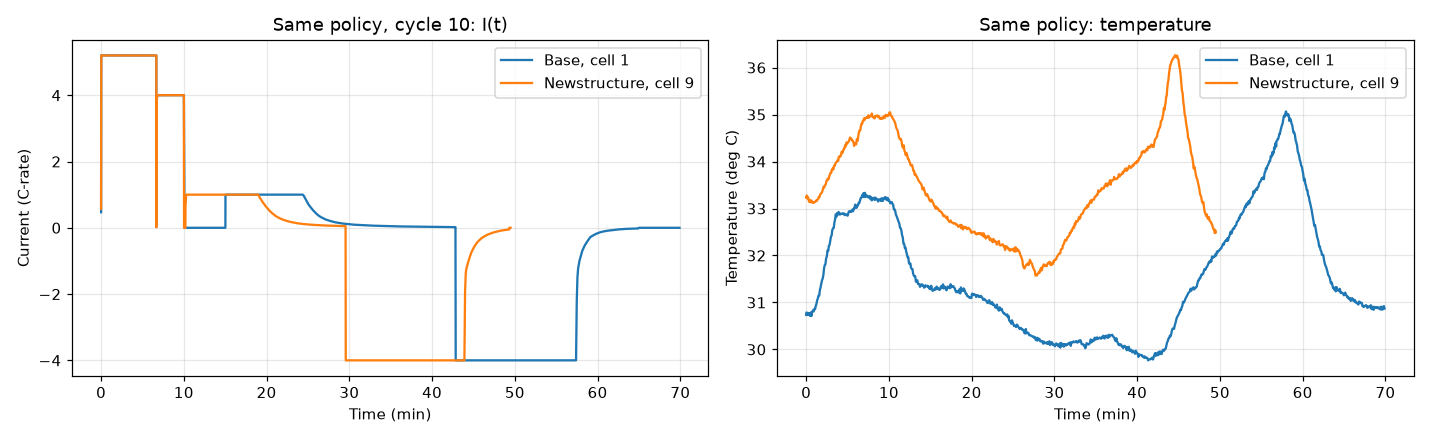

In [12]:
def read_raw_cycle(batch_name, cell_id, cycle):
    """사이클 번호를 찾아, 그 사이클의 원본 전류·전압·시간 등을 읽습니다."""
    raw_path = PROJECT_ROOT / "data" / f"{batch_name.capitalize()}.mat"
    with h5py.File(raw_path, "r") as f:
        batch = f["batch"]
        assert 1 <= cell_id <= batch["cycles"].shape[0], "셀 ID 범위를 확인하세요."
        summary_group = f[batch["summary"][cell_id - 1, 0]]
        stored_cycles = summary_group["cycle"][()].ravel()
        matches = np.flatnonzero(stored_cycles == cycle)
        assert len(matches) == 1, f"{batch_name}, cell {cell_id}: cycle {cycle} 없음"
        group = f[batch["cycles"][cell_id - 1, 0]]
        assert group["I"].shape[0] == len(stored_cycles), "요약 데이터와 원본의 사이클 개수가 다릅니다."
        result = {key: f[group[key][matches[0], 0]][()].ravel() for key in ["I", "V", "t", "T", "Qd"]}
    assert len({len(value) for value in result.values()}) == 1
    assert all(np.isfinite(value).all() for value in result.values())
    assert np.all(np.diff(result["t"]) >= 0), "원본 시간이 거꾸로 가는 부분이 있습니다. 쉬는 시간을 계산하기 전에 확인하세요."
    return result

CONDITION_CYCLE = 10
MATCH_PROTOCOL = "5.2C(58%)-4C"
REST_THRESHOLD = 0.01
condition_rows, raw_batch2 = [], {}
for cell_id in batch2["cell_id"]:
    raw = read_raw_cycle("batch2", int(cell_id), CONDITION_CYCLE)
    raw_batch2[cell_id] = raw
    dt = np.diff(raw["t"])
    rest = (np.abs(raw["I"][:-1]) <= REST_THRESHOLD) & (np.abs(raw["I"][1:]) <= REST_THRESHOLD)
    condition_rows.append({
        "cell_id": cell_id, "rest_minutes": dt[rest].sum(),
        "cycle_minutes": raw["t"][-1] - raw["t"][0], "peak_temperature": raw["T"].max(),
    })
conditions = batch2.merge(pd.DataFrame(condition_rows), on="cell_id", validate="one_to_one")
display(conditions.groupby("variant")[["rest_minutes", "cycle_minutes", "peak_temperature"]].agg(["count", "median", "min", "max"]).round(3))
matched = conditions.loc[conditions["protocol"].eq(MATCH_PROTOCOL) & conditions["variant"].isin(["Base", "Newstructure"])]
assert matched["variant"].nunique() == 2, "비교할 정책에 Base와 Newstructure가 모두 있어야 합니다."
display(matched[["cell_id", "policy", "cycle_life", "rest_minutes", "cycle_minutes", "peak_temperature"]].round(3))

# 각 그룹의 첫 셀을 그래프 예시로 봅니다. 다른 셀의 값은 위 표에서 확인합니다.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for variant, group in matched.groupby("variant"):
    cell_id = int(group["cell_id"].iloc[0])
    raw = raw_batch2[cell_id]
    label = f"{variant}, cell {cell_id}"
    axes[0].plot(raw["t"], raw["I"], label=label)
    axes[1].plot(raw["t"], raw["T"], label=label)
axes[0].set(title=f"Same policy, cycle {CONDITION_CYCLE}: I(t)", xlabel="Time (min)", ylabel="Current (C-rate)")
axes[1].set(title="Same policy: temperature", xlabel="Time (min)", ylabel="Temperature (deg C)")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

### 지금까지의 조건 비교에서 알 수 있는 점

충전 전류와 전환 시점의 숫자가 같아도 쉬는 시간과 진행 순서가 다를 수 있습니다. 그래서 `first_c_rate`, `switch_soc`, `second_c_rate` 세 값만으로 수명 차이를 모두 설명하기는 어렵습니다.

다만 비교한 셀이 적고, 두 그룹에 셀을 무작위로 나눴는지도 모릅니다. **쉬는 시간이 길어서 수명이 짧아졌다고 결론 내리려면 더 확인해야 합니다.**

평균 온도는 오래 쉬면서 낮아질 수 있습니다. 아래처럼 최대 온도와 전류·시간 그래프를 함께 보는 이유입니다. 다음에는 같은 충전 방법의 여러 셀과 여러 초기 사이클에서 쉬는 시간, 많이 충전된 상태로 머무는 시간, 지금까지 걸린 총시간을 비교하면 좋습니다.

## 5. Q가 가파르게 변하는 구간을 원본에서도 확인하기

위의 `BATCH`, `CELL_ID`, `CYCLES`를 그대로 사용합니다. Q(V)에서 가파른 구간이 V(Q)에서는 평평하게 보일 수 있습니다. **전압이 거의 변하지 않는 동안 용량이 많이 변하기 때문**입니다. 이런 전압 구간을 **plateau(평탄한 구간)**라고 부릅니다.

`|dQ/dV|`는 전압이 조금 변할 때 용량이 얼마나 많이 변하는지 나타냅니다. 값이 큰 전압 구간을 찾아 봅니다. 초기 곡선이 전압 방향으로 조금만 움직여도 이런 구간에서는 ΔQ(V)가 커질 수 있습니다.

공개 생성 코드에서는 방전 전류와 시간으로 용량을 계산한 뒤, 측정점들을 부드러운 곡선으로 연결해 같은 전압 1000개에서 값을 구합니다. 이때 쓰는 방법이 **smoothing spline**입니다. 아래 그래프에서는 저장된 `Qdlin`, 원본 용량 `Qd`, 전류·시간으로 계산한 용량을 함께 그립니다. [VQlinspace3.m](https://github.com/chueh-ermon/BMS-autoanalysis/blob/master/VQlinspace3.m)

Qd와 Qdlin은 계산 방식이나 사용한 방전 구간이 달라 값이 조금 다를 수 있습니다. 일정 전류로 방전하는 구간(CC)과 일정 전압으로 방전하는 구간(CV)이 포함되는 범위도 확인합니다.

가파른 모양이 원본에도 있으면 실제 측정된 변화일 가능성이 있습니다. 보간한 곡선에서만 보이면 곡선을 만드는 과정을 먼저 확인합니다. 가파른 구간 하나만으로 어떤 배터리 손상이 생겼는지 결정하지는 않습니다.

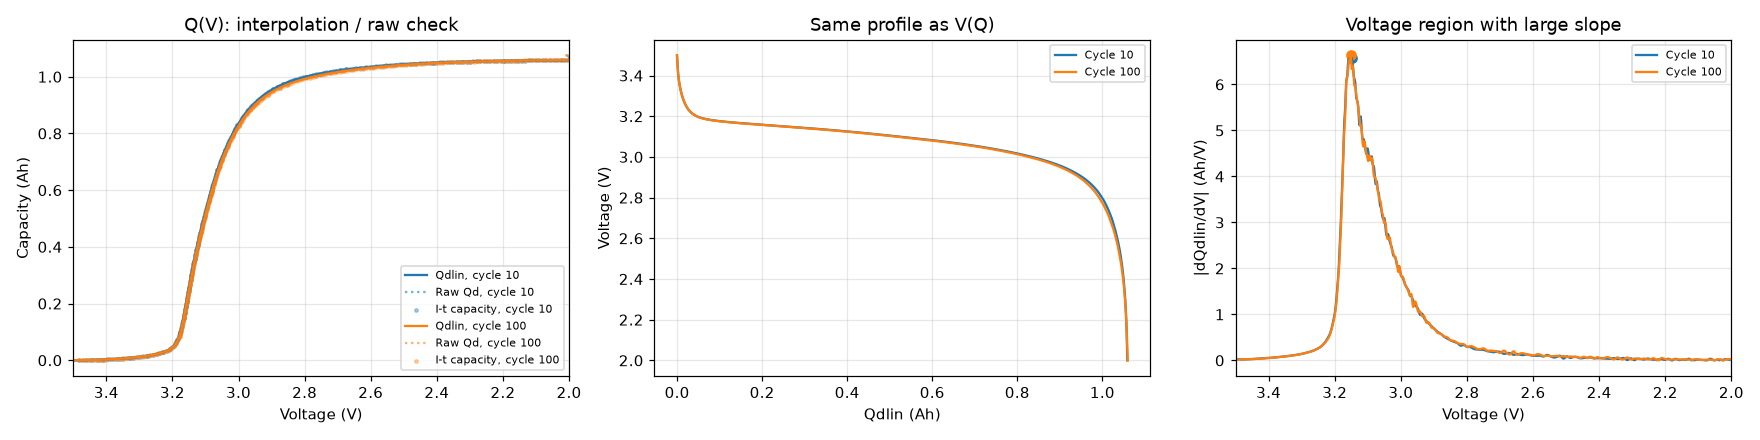

,cycle,steepest_voltage,abs_dqdv
0,10,3.1486,6.5777
1,100,3.1517,6.6359


In [13]:
V_WINDOW = (2.7, 3.4)  # 전압의 끝부분을 빼고 가장 가파른 구간을 찾습니다.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
peak_rows = []
for cycle, q_curve in zip(CYCLES, q_curves):
    line, = axes[0].plot(voltage, q_curve, label=f"Qdlin, cycle {cycle}")
    color = line.get_color()
    raw = read_raw_cycle(BATCH, CELL_ID, cycle)
    discharge = (raw["I"] < -0.02) & (raw["Qd"] > 0)
    axes[0].plot(raw["V"][discharge], raw["Qd"][discharge], ":", color=color, alpha=0.6, label=f"Raw Qd, cycle {cycle}")
    # 일정한 전류로 방전한 구간에서 전류와 시간으로 용량을 계산합니다.
    rounded, counts = np.unique(np.round(raw["I"][raw["I"] < -0.5]), return_counts=True)
    main_rate = rounded[np.argmax(counts)]
    cc = np.flatnonzero(np.abs(raw["I"] - main_rate) < 0.05)
    assert len(cc) >= 3 and main_rate < 0
    cc = cc[:np.argmin(raw["V"][cc[:-2]]) + 1]
    q_from_it = -(raw["t"][cc] - raw["t"][cc[0]]) * raw["I"][cc] * 1.1 / 60
    axes[0].scatter(raw["V"][cc], q_from_it, s=5, color=color, alpha=0.35, label=f"I-t capacity, cycle {cycle}")
    axes[1].plot(q_curve, voltage, color=color, label=f"Cycle {cycle}")
    slope = np.abs(np.gradient(q_curve, voltage))
    axes[2].plot(voltage, slope, color=color, label=f"Cycle {cycle}")
    inside = np.flatnonzero((voltage >= V_WINDOW[0]) & (voltage <= V_WINDOW[1]))
    peak = inside[np.argmax(slope[inside])]
    axes[2].scatter(voltage[peak], slope[peak], color=color)
    peak_rows.append({"cycle": cycle, "steepest_voltage": voltage[peak], "abs_dqdv": slope[peak]})
axes[0].set(title="Q(V): interpolation / raw check", xlabel="Voltage (V)", ylabel="Capacity (Ah)", xlim=(3.5, 2.0))
axes[1].set(title="Same profile as V(Q)", xlabel="Qdlin (Ah)", ylabel="Voltage (V)")
axes[2].set(title="Voltage region with large slope", xlabel="Voltage (V)", ylabel="|dQdlin/dV| (Ah/V)", xlim=(3.5, 2.0))
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()
display(pd.DataFrame(peak_rows).round(4))

## 6. 용량이 더 빠르게 줄어들기 시작하는 지점(knee) 찾기

**knee**는 용량이 서서히 줄다가 더 빠르게 줄어들기 시작하는 꺾임입니다. 가능한 이유로는 리튬이 음극 표면에 쌓이는 현상, 전극이 저장할 수 있는 양의 변화, 내부저항 증가, 전해액 변화 등이 있습니다.

저항이 커져 방전 중 전압이 더 많이 떨어지면, 방전을 끝내는 전압에 더 빨리 도달해 측정 용량이 빠르게 줄 수도 있습니다. 어느 이유가 맞는지는 용량 곡선만으로 알기 어렵습니다. [Attia et al. (2022), knee가 생기는 여러 이유](https://arxiv.org/html/2201.02891v1)

여기서는 **이어 붙인 두 직선**으로 꺾임 위치를 찾아 봅니다. 사이클 100부터 보고, 꺾임의 앞뒤에 측정값을 최소 50개씩 남깁니다. 직선 하나보다 실제 값과의 차이(SSE)가 10% 이상 줄고, 뒤쪽 용량이 더 빠르게 감소할 때 후보로 표시합니다. SSE는 실제 값과 직선의 차이를 제곱해서 더한 값입니다. 이 기준은 실험용으로 정한 값입니다.

주변 **11개·21개·41개 값의 중앙값**을 써서 튀는 값을 줄이고, 꺾임 위치가 비슷하게 나오는지 봅니다. 이를 코드에서는 `rolling median`이라고 합니다. 원본 그래프도 함께 그리며 내부저항 0은 그대로 둡니다. 수명값을 아는 셀은 그 이후 기록을 꺾임 찾기에서 뺍니다.

**이 꺾임은 나중의 기록까지 보고 찾은 값입니다. 처음 100사이클만으로 수명을 예측하는 모델에 넣으면, 아직 알 수 없는 미래 정보를 미리 알려 주는 문제가 생깁니다.** 이를 data leakage라고 합니다.

기본 예시는 `KNEE_BATCH="batch2"`, `KNEE_CELL_ID=1`입니다. Q(V)를 그린 셀과 따로 바꿀 수 있습니다. Batch1 cell 1은 마지막 기록에도 용량이 높아서, 측정이 끝나기 전에 뚜렷한 꺾임이 나타나지 않았을 수도 있습니다.

,batch,cell_id,policy,cycle_life
46,batch2,1,5.2C(58%)-4C,477.0


,window,knee_cycle,slope_before,slope_after,sse_gain,candidate
0,11,381.417722,-0.000191,-0.001856,0.928203,True
1,21,381.417722,-0.000192,-0.001836,0.929799,True
2,41,377.911392,-0.000188,-0.001713,0.930083,True


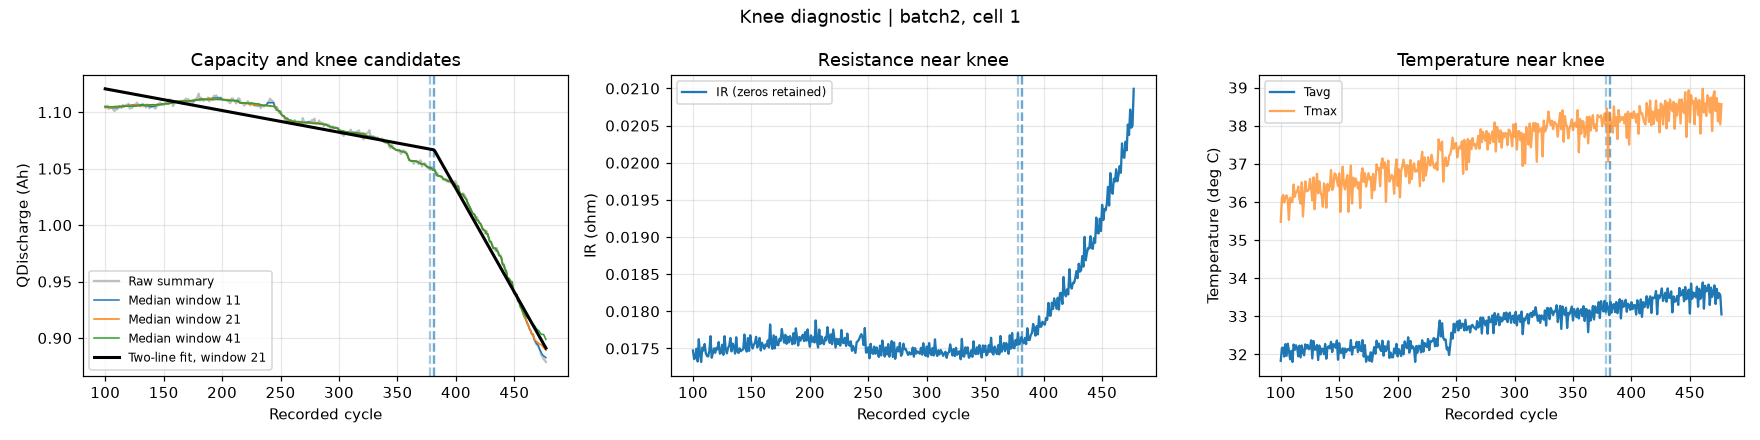

꺾임을 찾은 주변값 묶기 방법: 3/3


In [14]:
# 수명이 짧은 Batch2 cell 1에서 꺾임을 찾아 봅니다. 다른 셀로 바꿀 수 있습니다.
KNEE_BATCH = "batch2"
KNEE_CELL_ID = 1
KNEE_START_CYCLE = 100
KNEE_WINDOWS = [11, 21, 41]
MIN_SEGMENT_POINTS = 50
MIN_SSE_GAIN = 0.10

def fit_knee(x, y):
    """이어 붙인 두 직선으로 꺾임을 찾습니다. 직선이면 꺾임이 없다고 봅니다."""
    if len(x) < 2 * MIN_SEGMENT_POINTS + 1:
        return None
    base = np.column_stack([np.ones(len(x)), x])
    base_fit = base @ np.linalg.lstsq(base, y, rcond=None)[0]
    base_sse = np.sum((y - base_fit) ** 2)
    if base_sse <= 1e-12:
        return None
    best = None
    for knee in np.linspace(x[MIN_SEGMENT_POINTS], x[-MIN_SEGMENT_POINTS - 1], 80):
        design = np.column_stack([base, np.maximum(0, x - knee)])
        coef = np.linalg.lstsq(design, y, rcond=None)[0]
        fit = design @ coef
        sse = np.sum((y - fit) ** 2)
        if best is None or sse < best["sse"]:
            best = {"knee_cycle": knee, "sse": sse, "fit": fit,
                    "slope_before": coef[1], "slope_after": coef[1] + coef[2]}
    best["sse_gain"] = 1 - best["sse"] / base_sse
    best["candidate"] = (best["sse_gain"] >= MIN_SSE_GAIN and
                         best["slope_after"] < min(best["slope_before"], 0))
    return best

# 꺾임 위치를 아는 예시와 그냥 직선인 예시로 코드가 맞게 동작하는지 확인합니다.
toy_x = np.arange(1, 301, dtype=float)
toy_y = 1.1 - 0.00005 * toy_x - 0.0005 * np.maximum(0, toy_x - 180)
toy_result = fit_knee(toy_x, toy_y)
assert toy_result["candidate"] and abs(toy_result["knee_cycle"] - 180) < 5
assert fit_knee(toy_x, 1.1 - 0.0001 * toy_x) is None

track = all_summary.loc[all_summary["batch"].eq(KNEE_BATCH) & all_summary["cell_id"].eq(KNEE_CELL_ID)].sort_values("cycle").copy()
knee_cell = all_cells.loc[all_cells["batch"].eq(KNEE_BATCH) & all_cells["cell_id"].eq(KNEE_CELL_ID)]
assert len(knee_cell) == 1, "knee 분석의 배치와 셀 ID를 확인하세요."
life = knee_cell["cycle_life"].iloc[0]
display(knee_cell[KEYS + ["policy", "cycle_life"]])
if pd.notna(life):
    track = track.loc[track["cycle"] <= life].copy()
track = track.loc[track["cycle"] >= KNEE_START_CYCLE].dropna(subset=["QDischarge"])
assert not track.empty, "KNEE_START_CYCLE 이후 용량 데이터가 없습니다. 시작 cycle을 확인하세요."
x = track["cycle"].to_numpy(dtype=float)
q = track["QDischarge"].to_numpy()
results, fits = [], {}
for window in KNEE_WINDOWS:
    smooth = pd.Series(q).rolling(window, center=True, min_periods=1).median().to_numpy()
    result = fit_knee(x, smooth)
    if result is None:
        results.append({"window": window, "candidate": False})
        continue
    fits[window] = (smooth, result)
    results.append({"window": window, **{key: value for key, value in result.items() if key not in ["fit", "sse"]}})
knee_results = pd.DataFrame(results)
display(knee_results.round(6))
accepted = knee_results.loc[knee_results["candidate"].eq(True)]
print(f"꺾임을 찾은 주변값 묶기 방법: {len(accepted)}/{len(KNEE_WINDOWS)}")
if len(accepted) != len(KNEE_WINDOWS):
    print("주변값을 묶는 방법에 따라 꺾임이 보이거나 안 보입니다. 원본을 보고 시작 사이클도 바꿔 보세요.")
elif accepted["knee_cycle"].max() - accepted["knee_cycle"].min() > 20:
    print("주변값을 몇 개씩 묶느냐에 따라 꺾임 위치가 20사이클 넘게 달라집니다.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(x, q, color="gray", alpha=0.5, label="Raw summary")
for window, (smooth, result) in fits.items():
    axes[0].plot(x, smooth, linewidth=1, label=f"Median window {window}")
    if result["candidate"]:
        for ax in axes:
            ax.axvline(result["knee_cycle"], linestyle="--", alpha=0.4)
if 21 in fits:
    axes[0].plot(x, fits[21][1]["fit"], color="black", linewidth=2, label="Two-line fit, window 21")
axes[1].plot(x, track["IR"], label="IR (zeros retained)")
axes[2].plot(x, track["Tavg"], label="Tavg")
axes[2].plot(x, track["Tmax"], label="Tmax", alpha=0.7)
for ax, title, ylabel in zip(axes, ["Capacity and knee candidates", "Resistance near knee", "Temperature near knee"], ["QDischarge (Ah)", "IR (ohm)", "Temperature (deg C)"]):
    ax.set(title=title, xlabel="Recorded cycle", ylabel=ylabel)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle(f"Knee diagnostic | {KNEE_BATCH}, cell {KNEE_CELL_ID}")
plt.tight_layout()
plt.show()

## 7. 같은 충전 방법에서 꺾임은 얼마나 늦어졌나?

Batch2에서 수명이 기록된 39개 셀의 꺾임을 같은 방법으로 찾습니다. 주변값을 11·21·41개씩 묶었을 때 모두 후보가 나오고, 위치 차이가 20사이클 이하면 이번 비교에 사용합니다. 꺾임을 못 찾은 셀도 아래 표에 남깁니다. 이 기준은 실험용이며 정확한 물리적 전환 시점을 뜻하지는 않습니다.

먼저 기본/`newstructure` 모두 있는 **같은 충전 방법끼리** 비교합니다. 수명뿐 아니라 꺾임 시점, 꺾임 앞뒤의 용량 감소 속도를 봅니다. 감소 속도 비율은 뒤쪽 속도를 앞쪽 속도로 나눈 값입니다. 앞쪽 변화가 거의 없으면 이 비율은 크게 나올 수 있습니다.

,n_cells,usable_knees
variant,,
Base,30,29
Newstructure,9,9


,batch,cell_id,protocol,candidate_windows
17,batch2,18,5.6C(26%)-4.5C,3


n_cells  ...  median_speed_ratio
protocol       variant                ...                    
4.8C(80%)-4.8C Base                5  ...                6.62
               Newstructure        3  ...                6.92
5.2C(58%)-4C   Base                4  ...               15.25
               Newstructure        3  ...               17.92
5.6C(26%)-4.5C Base                5  ...                4.84
               Newstructure        3  ...               13.14

[6 rows x 4 columns]

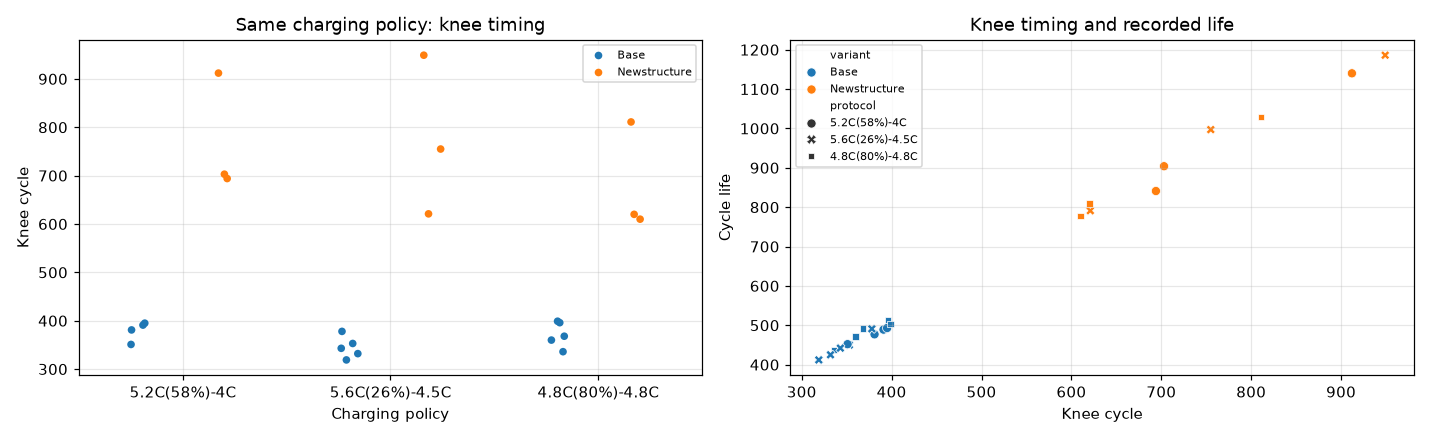

In [15]:
# 기존 꺾임 찾기 함수를 여러 셀에 같은 기준으로 적용합니다.
knee_rows = []
for row in batch2.dropna(subset=["cycle_life"]).itertuples(index=False):
    track = all_summary.loc[
        all_summary["batch"].eq("batch2") & all_summary["cell_id"].eq(row.cell_id)
        & all_summary["cycle"].between(KNEE_START_CYCLE, row.cycle_life)
    ].sort_values("cycle").dropna(subset=["QDischarge"])
    x = track["cycle"].to_numpy(dtype=float)
    q = track["QDischarge"].to_numpy()
    found = {}
    for window in KNEE_WINDOWS:
        smooth = pd.Series(q).rolling(window, center=True, min_periods=1).median().to_numpy()
        result = fit_knee(x, smooth)
        if result is not None and result["candidate"]:
            found[window] = result
    stable = len(found) == len(KNEE_WINDOWS) and np.ptp([f["knee_cycle"] for f in found.values()]) <= 20
    record = {"batch": "batch2", "cell_id": row.cell_id, "protocol": row.protocol,
              "variant": row.variant, "cycle_life": row.cycle_life, "stable_knee": stable,
              "candidate_windows": len(found)}
    if stable:
        fit = found[21]
        record.update(knee_cycle=int(round(fit["knee_cycle"])),
                      slope_before=fit["slope_before"], slope_after=fit["slope_after"],
                      speed_ratio=abs(fit["slope_after"] / fit["slope_before"]) if fit["slope_before"] < 0 else np.nan)
    knee_rows.append(record)
knees = pd.DataFrame(knee_rows)
display(knees.groupby("variant").agg(n_cells=("cell_id", "size"), usable_knees=("stable_knee", "sum")))
display(knees.loc[~knees["stable_knee"], KEYS + ["protocol", "candidate_windows"]])

# 두 그룹에서 모두 쓰인 충전 방법만 골라 표와 그래프를 만듭니다.
stable_knees = knees.loc[knees["stable_knee"]].copy()
shared = stable_knees.groupby("protocol")["variant"].nunique().loc[lambda s: s == 2].index
paired_knees = stable_knees.loc[stable_knees["protocol"].isin(shared)].copy()
display(paired_knees.groupby(["protocol", "variant"]).agg(
    n_cells=("cell_id", "size"), median_knee=("knee_cycle", "median"),
    median_life=("cycle_life", "median"), median_speed_ratio=("speed_ratio", "median")
).round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.stripplot(data=paired_knees, x="protocol", y="knee_cycle", hue="variant", dodge=True, jitter=0.1, ax=axes[0])
sns.scatterplot(data=paired_knees, x="knee_cycle", y="cycle_life", hue="variant", style="protocol", ax=axes[1])
axes[0].set(title="Same charging policy: knee timing", xlabel="Charging policy", ylabel="Knee cycle")
axes[1].set(title="Knee timing and recorded life", xlabel="Knee cycle", ylabel="Cycle life")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 8. 꺾임 전후에 방식이 바뀌었나, 셀의 상태가 바뀌었나?

꺾임이 비교적 일정하게 나온 셀에서 **꺾임 50사이클 전과 50사이클 후**를 읽습니다. 전류·쉬는 시간이 갑자기 달라졌는지, 그대로인데 저항·전압·용량이 달라졌는지 확인합니다.

- 충전 전류는 순간적으로 튀는 값의 영향을 줄이려고 높은 쪽 대표값(95% 위치의 값)을 사용합니다.
- 방전 전류는 0.5C보다 큰 방전 전류 중 가장 자주 나타나는 구간에서 구합니다. 마지막의 작은 전류가 주 방전 전류로 잘못 선택되지 않게 합니다.
- `high_voltage_minutes`는 충전·휴지 중 **3.5 V 이상으로 머문 시간**입니다. 정확한 SOC를 계산한 값은 아닙니다.
- 내부저항·온도·용량은 해당 사이클 주변 11개 값의 중앙값을 사용합니다. 내부저항 0도 그대로 남깁니다.
- `voltage_at_q05`는 방전 용량 0.5 Ah에 가장 가까운 전압입니다. 같은 양을 방전했을 때도 전압이 더 낮아지는지 봅니다.

비교 결과는 뒤쪽 값에서 앞쪽 값을 뺀 것입니다. 두 시점의 전류가 비슷하더라도 자세한 단계 순서는 아래 원본 그래프에서 함께 확인합니다.

,delta_IR,delta_Tmax,delta_capacity,delta_charge_c,delta_discharge_c,delta_rest_minutes,delta_high_voltage_minutes,delta_cc_minutes,delta_cc_end_voltage,delta_voltage_at_q05
variant,,,,,,,,,,
Base,0.00116,0.38498,-0.08107,-0.00032,0.00001,0.00004,1.36648,-1.64737,0.00152,-0.04354
Newstructure,0.00011,0.29945,-0.03452,0.00007,-0.00002,-0.00001,0.71080,-0.63278,-0.00052,-0.01502


,check,n_cells,total_cells
0,charge change > 0.05C,4,38
1,discharge change > 0.05C,0,38
2,rest change > 0.1 min,0,38
3,IR increased,32,38
4,Tmax increased,35,38
5,voltage at 0.5 Ah decreased,38,38
6,CC discharge shortened,38,38


,delta_IR,simple_ir_voltage_change,delta_voltage_at_q05
variant,,,
Base,0.00116,-0.00509,-0.04354
Newstructure,0.00011,-0.00049,-0.01502


,cell_id,stage,cycle,IR,Tmax,capacity,voltage_at_q05,charge_c,discharge_c,rest_minutes,high_voltage_minutes,cc_minutes,cc_end_voltage
0,1,Before,331,0.01743,38.05133,1.07757,3.07207,5.20229,4.00018,9.84660,26.90424,13.17639,2.00350
1,1,After,431,0.01855,38.48842,0.98227,3.02553,5.20092,4.00015,9.84683,27.53750,11.43237,1.99850
16,9,Before,653,0.01680,37.06338,1.06647,3.07958,5.20253,4.00019,0.31356,15.84374,13.39699,2.00422
17,9,After,753,0.01698,37.18168,1.03195,3.06456,5.20169,4.00014,0.31317,16.58206,12.76421,2.00680


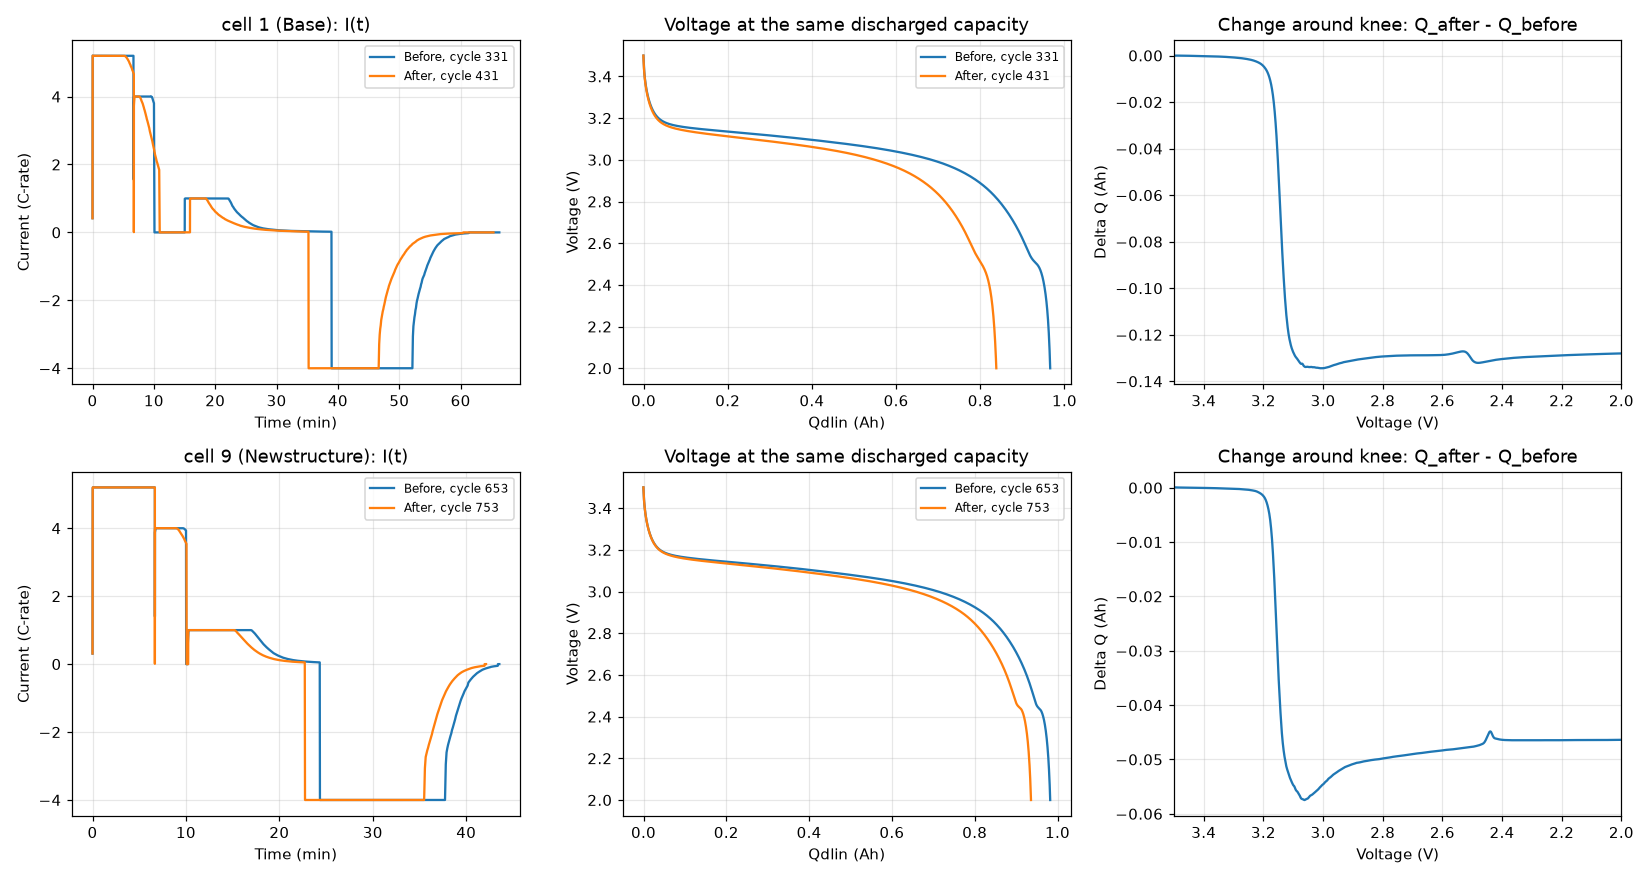

In [16]:
def describe_raw_cycle(raw):
    """원본에서 전류, 쉬는 시간, 높은 전압으로 머문 시간 등을 계산합니다."""
    dt = np.diff(raw["t"])
    rest = (np.abs(raw["I"][:-1]) <= REST_THRESHOLD) & (np.abs(raw["I"][1:]) <= REST_THRESHOLD)
    high_v = (raw["V"][:-1] >= 3.5) & (raw["V"][1:] >= 3.5) & (raw["I"][:-1] >= -REST_THRESHOLD) & (raw["I"][1:] >= -REST_THRESHOLD)
    fast_charge = raw["I"][raw["I"] > 1.2]
    rates, counts = np.unique(np.round(raw["I"][raw["I"] < -0.5]), return_counts=True)
    assert len(fast_charge) and len(rates), "충전·방전 구간을 찾지 못했습니다."
    main_rate = rates[np.argmax(counts)]
    cc = np.flatnonzero(np.abs(raw["I"] - main_rate) < 0.05)
    assert len(cc) >= 3 and main_rate < 0
    return {"charge_c": np.quantile(fast_charge, 0.95),
            "discharge_c": abs(np.median(raw["I"][cc])),
            "rest_minutes": dt[rest].sum(), "high_voltage_minutes": dt[high_v].sum(),
            "cc_minutes": raw["t"][cc[-1]] - raw["t"][cc[0]],
            "cc_end_voltage": raw["V"][cc].min()}

stage_rows, stage_raw, stage_q = [], {}, {}
with np.load(DATA_DIR / "batch2_cycle_profiles.npz", allow_pickle=False) as archive:
    for row in stable_knees.itertuples(index=False):
        saved_cycles = archive[f"cell_{row.cell_id}_cycle"]
        qdlin = archive[f"cell_{row.cell_id}_qdlin"]
        assert qdlin.shape == (len(saved_cycles), len(voltage))
        for stage, requested in [("Before", row.knee_cycle - 50), ("After", row.knee_cycle + 50)]:
            cycle = int(saved_cycles[np.argmin(np.abs(saved_cycles - min(requested, row.cycle_life)))])
            raw = read_raw_cycle("batch2", int(row.cell_id), cycle)
            q_curve = qdlin[np.flatnonzero(saved_cycles == cycle)[0]]
            nearby = all_summary.loc[all_summary["batch"].eq("batch2") & all_summary["cell_id"].eq(row.cell_id)
                                      & all_summary["cycle"].between(cycle - 5, min(cycle + 5, row.cycle_life))]
            record = {"cell_id": row.cell_id, "stage": stage, "cycle": cycle,
                      "IR": nearby["IR"].median(), "Tmax": nearby["Tmax"].median(),
                      "capacity": nearby["QDischarge"].median(),
                      "voltage_at_q05": voltage[np.argmin(np.abs(q_curve - 0.5))],
                      **describe_raw_cycle(raw)}
            stage_rows.append(record)
            stage_raw[(row.cell_id, stage)] = raw
            stage_q[(row.cell_id, stage)] = q_curve.copy()
        del qdlin
stages = pd.DataFrame(stage_rows)
metrics = ["IR", "Tmax", "capacity", "charge_c", "discharge_c", "rest_minutes",
           "high_voltage_minutes", "cc_minutes", "cc_end_voltage", "voltage_at_q05"]
changes = stages.pivot(index="cell_id", columns="stage", values=metrics)
changes = pd.DataFrame({f"delta_{name}": changes[(name, "After")] - changes[(name, "Before")] for name in metrics}).reset_index()
changes = stable_knees.merge(changes, on="cell_id", validate="one_to_one")
display(changes.groupby("variant")[[f"delta_{name}" for name in metrics]].median().round(5))

# 같은 전류를 유지하면서 전압과 용량이 낮아지는 셀이 얼마나 있는지 셉니다.
check_counts = pd.DataFrame({
    "check": ["charge change > 0.05C", "discharge change > 0.05C", "rest change > 0.1 min",
              "IR increased", "Tmax increased", "voltage at 0.5 Ah decreased", "CC discharge shortened"],
    "n_cells": [changes["delta_charge_c"].abs().gt(0.05).sum(), changes["delta_discharge_c"].abs().gt(0.05).sum(),
                changes["delta_rest_minutes"].abs().gt(0.1).sum(), changes["delta_IR"].gt(0).sum(),
                changes["delta_Tmax"].gt(0).sum(), changes["delta_voltage_at_q05"].lt(0).sum(), changes["delta_cc_minutes"].lt(0).sum()]
})
check_counts["total_cells"] = len(changes)
display(check_counts)

# 저항 변화로 생길 단순 전압 차이의 크기만 비교합니다. 원인별 기여도를 구하는 계산은 아닙니다.
current_after = stages.loc[stages["stage"].eq("After"), ["cell_id", "discharge_c"]]
changes = changes.merge(current_after, on="cell_id", validate="one_to_one")
changes["simple_ir_voltage_change"] = -changes["discharge_c"] * 1.1 * changes["delta_IR"]
display(changes.groupby("variant")[["delta_IR", "simple_ir_voltage_change", "delta_voltage_at_q05"]].median().round(5))

# 같은 정책의 기본 cell 1과 newstructure cell 9를 예시로 봅니다.
EXAMPLE_CELLS = [1, 9]
assert set(EXAMPLE_CELLS) <= set(stable_knees["cell_id"]), "예시 셀에 일정한 꺾임이 있는지 확인하세요."
display(stages.loc[stages["cell_id"].isin(EXAMPLE_CELLS)].round(5))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, cell_id in enumerate(EXAMPLE_CELLS):
    for stage in ["Before", "After"]:
        raw = stage_raw[(cell_id, stage)]
        q_curve = stage_q[(cell_id, stage)]
        cycle = int(stages.loc[stages["cell_id"].eq(cell_id) & stages["stage"].eq(stage), "cycle"].iloc[0])
        label = f"{stage}, cycle {cycle}"
        axes[row, 0].plot(raw["t"], raw["I"], label=label)
        axes[row, 1].plot(q_curve, voltage, label=label)
    axes[row, 2].plot(voltage, stage_q[(cell_id, "After")] - stage_q[(cell_id, "Before")])
    variant = stable_knees.loc[stable_knees["cell_id"].eq(cell_id), "variant"].iloc[0]
    axes[row, 0].set(title=f"cell {cell_id} ({variant}): I(t)", xlabel="Time (min)", ylabel="Current (C-rate)")
    axes[row, 1].set(title="Voltage at the same discharged capacity", xlabel="Qdlin (Ah)", ylabel="Voltage (V)")
    axes[row, 2].set(title="Change around knee: Q_after - Q_before", xlabel="Voltage (V)", ylabel="Delta Q (Ah)", xlim=(3.5, 2.0))
    for ax in axes[row]:
        ax.grid(alpha=0.3)
    axes[row, 0].legend(fontsize=8)
    axes[row, 1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 이 비교로 원인을 어디까지 좁힐 수 있나?

- **운전 방법이 꺾임 순간에 바뀌었는가?** 앞뒤의 전류 크기와 쉬는 시간을 봅니다. 값이 그대로라면 그 순간의 전류·휴지 변경으로 꺾임을 설명하기는 어렵습니다. 상세 단계 순서도 원본 그래프에서 확인합니다.
- **이전부터의 조건 차이가 손상을 쌓았는가?** 기본/`newstructure`는 처음부터 쉬는 시간과 높은 전압에 머문 시간이 달랐습니다. 같은 정책에서 꺾임도 늦어졌다면 이런 조건 차이는 먼저 확인할 원인 후보입니다. 셀 자체의 차이도 함께 섞여 있을 수 있습니다.
- **저항·전압 변화가 방전 성능을 낮추는가?** 같은 방전 전류에서 저항이 올라가고 같은 용량의 전압이 낮아지면, 방전을 끝내는 전압에 더 빨리 닿아 용량이 줄 수 있습니다. 표의 단순 `전류 × 저항 변화`는 변화 크기를 비교하는 용도입니다. summary의 저항과 방전 전압은 측정 상태가 다를 수 있어, 이 값으로 저항의 원인 비율을 계산하지 않습니다.
- **Q(V)의 가파른 부분은 어떻게 연결되는가?** 그 모양 자체가 손상의 원인인지는 알 수 없습니다. 다만 가파른 구간에서는 작은 전압 이동도 큰 ΔQ(V)로 나타날 수 있으므로, 실제 전압 저하와 연결되는지 확인할 가치가 있습니다.

저항 증가, 전극·전해액 변화, 리튬이 음극 표면에 쌓이는 현상 등은 서로 영향을 줄 수 있습니다. 지금 비교는 원인 후보를 좁히는 단계입니다. [Attia et al. (2022), 꺾임 설명과 확인 방법](https://arxiv.org/html/2201.02891v1)

## 9. 초기에 보인 ΔQ(V) 변화가 더 이른 꺾임과 연결되는가?

cycle 10과 100의 차이 곡선에서 전압별 차이의 분산을 계산합니다. 앞의 전체 수명 관계도 참고로 남기고, 마지막에는 **꺾임 시점과의 관계**를 따로 봅니다.

분산이 큰 셀의 꺾임이 일찍 나오면, 초기 Q(V) 변화는 이후 급격한 용량 감소와 연결된 신호일 수 있습니다. 이것은 분산이 손상을 일으켰다는 뜻은 아닙니다. 같은 기본/`newstructure` 그룹 안에서도 관계가 남는지 확인합니다.

상관계수는 −1에 가까울수록 값이 클 때 꺾임 시점은 이른 경향이 강합니다. 사용한 셀 수 `n`도 봅니다. 전압축 끝부분의 영향은 전체 범위와 2.05~3.45 V만 사용한 계산을 비교해 확인합니다.

,n_cells,n_profiles,n_life
batch,,,
batch1,46,46,46
batch2,47,47,39
batch3,46,46,44


,group,feature,n,pearson_life,pearson_log10_life,spearman_life
0,All batches,log10_dqv_var,129,-0.851,-0.886,-0.892
1,All batches,log10_dqv_var_trimmed,129,-0.850,-0.887,-0.892
2,End Q <= 0.89 (sensitivity),log10_dqv_var,119,-0.857,-0.897,-0.888
3,End Q <= 0.89 (sensitivity),log10_dqv_var_trimmed,119,-0.856,-0.898,-0.888
4,batch1,log10_dqv_var,46,-0.886,-0.868,-0.871
5,batch1,log10_dqv_var_trimmed,46,-0.887,-0.869,-0.872
6,batch2,log10_dqv_var,39,-0.902,-0.918,-0.709
7,batch2,log10_dqv_var_trimmed,39,-0.901,-0.918,-0.705
8,batch3,log10_dqv_var,44,-0.702,-0.762,-0.797
9,batch3,log10_dqv_var_trimmed,44,-0.702,-0.762,-0.794


,batch,protocol,variant,n,spearman
0,batch2,4.8C(80%)-4.8C,Base,5,-0.900
1,batch2,5.2C(50%)-4.25C,Base,5,-0.316
2,batch2,5.2C(58%)-4C,Base,4,-0.200
3,batch2,5.6C(26%)-4.5C,Base,6,-0.429
4,batch3,4.8C(80%)-4.8C,Newstructure,6,0.143
5,batch3,5.3C(54%)-4C,Newstructure,8,-0.786
6,batch3,5.6C(19%)-4.6C,Newstructure,8,-0.452
7,batch3,5.6C(36%)-4.3C,Newstructure,8,0.095
8,batch3,5C(67%)-4C,Newstructure,7,-0.929


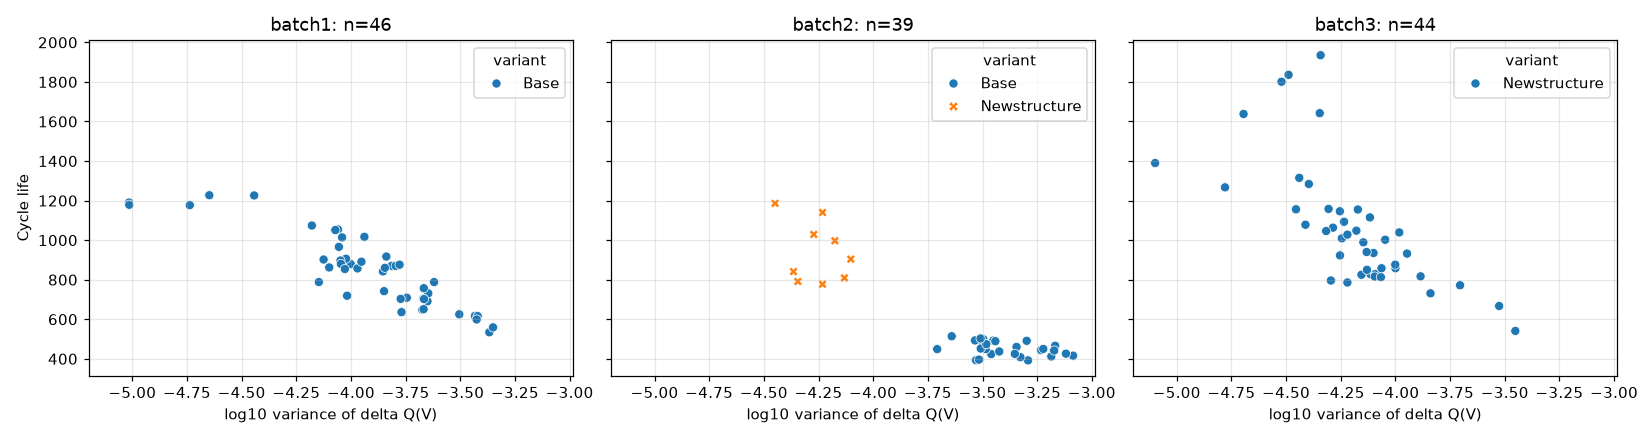

,group,n,spearman_with_knee
0,All Batch2,38,-0.761
1,Base,29,-0.485
2,Newstructure,9,-0.250


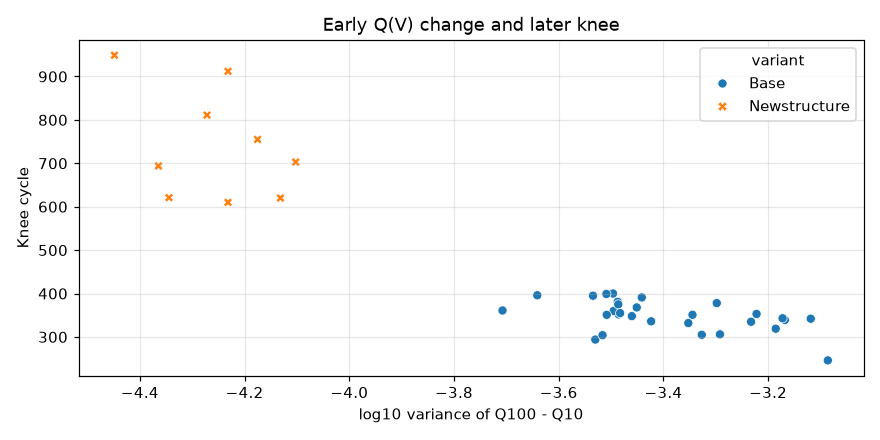

In [17]:
profile_rows = []
for batch_name in BATCHES:
    v = pd.read_csv(DATA_DIR / f"{batch_name}_vdlin.csv")["Vdlin"].to_numpy()
    assert np.allclose(v, voltage, rtol=0, atol=1e-12), "배치마다 비교에 쓰는 전압값이 다릅니다."
    trimmed = (v >= 2.05) & (v <= 3.45)
    with np.load(DATA_DIR / f"{batch_name}_cycle_profiles.npz", allow_pickle=False) as archive:
        for cell_id in all_cells.loc[all_cells["batch"].eq(batch_name), "cell_id"]:
            cycles = archive[f"cell_{cell_id}_cycle"]
            indices = [np.flatnonzero(cycles == cycle) for cycle in [10, 100]]
            if any(len(index) != 1 for index in indices):
                continue
            qdlin = archive[f"cell_{cell_id}_qdlin"]
            assert qdlin.shape == (len(cycles), len(v))
            delta = qdlin[indices[1][0]] - qdlin[indices[0][0]]
            assert np.isfinite(delta).all()
            variance, trimmed_variance = np.var(delta), np.var(delta[trimmed])
            profile_rows.append({"batch": batch_name, "cell_id": cell_id,
                "log10_dqv_var": np.log10(variance) if variance > 0 else np.nan,
                "log10_dqv_var_trimmed": np.log10(trimmed_variance) if trimmed_variance > 0 else np.nan})
            del qdlin
features = all_cells.merge(pd.DataFrame(profile_rows), on=KEYS, how="left", validate="one_to_one")
features["log10_life"] = np.log10(features["cycle_life"].where(features["cycle_life"] > 0))
assert len(features) == len(all_cells)
display(features.groupby("batch").agg(n_cells=("cell_id", "size"), n_profiles=("log10_dqv_var", "count"), n_life=("cycle_life", "count")))

known = features.dropna(subset=["cycle_life", "log10_dqv_var", "log10_dqv_var_trimmed"])
groups = [("All batches", known)]
# 마지막 용량이 기준 근처인 셀만 써도 상관계수가 비슷한지 확인합니다.
end_check = known.merge(endpoints[KEYS + ["last5_q_median"]], on=KEYS, validate="one_to_one")
groups.append(("End Q <= 0.89 (sensitivity)", end_check.loc[end_check["last5_q_median"] <= 0.89]))
groups += [(name, group) for name, group in known.groupby("batch")]
groups += [(f"{batch_name}/{variant}", group) for (batch_name, variant), group in known.groupby(["batch", "variant"])]
correlation_rows = []
for name, group in groups:
    for variable in ["log10_dqv_var", "log10_dqv_var_trimmed"]:
        enough = len(group) >= 3 and group[variable].nunique() > 1 and group["cycle_life"].nunique() > 1
        correlation_rows.append({"group": name, "feature": variable, "n": len(group),
            "pearson_life": group[variable].corr(group["cycle_life"]) if enough else np.nan,
            "pearson_log10_life": group[variable].corr(group["log10_life"]) if enough else np.nan,
            "spearman_life": group[variable].corr(group["cycle_life"], method="spearman") if enough else np.nan})
correlations = pd.DataFrame(correlation_rows)
display(correlations.round(3))

# 같은 숫자 충전 조건과 같은 운전 그룹 안에서도 관계가 보이는지 확인합니다.
policy_correlations = []
for keys, group in known.groupby(["batch", "protocol", "variant"]):
    if len(group) >= 4 and group["log10_dqv_var"].nunique() > 1 and group["cycle_life"].nunique() > 1:
        policy_correlations.append({"batch": keys[0], "protocol": keys[1], "variant": keys[2], "n": len(group),
            "spearman": group["log10_dqv_var"].corr(group["cycle_life"], method="spearman")})
display(pd.DataFrame(policy_correlations).round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, batch_name in zip(axes, BATCHES):
    group = known.loc[known["batch"].eq(batch_name)]
    sns.scatterplot(data=group, x="log10_dqv_var", y="cycle_life", hue="variant", style="variant", ax=ax)
    ax.set(title=f"{batch_name}: n={len(group)}", xlabel="log10 variance of delta Q(V)", ylabel="Cycle life")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 전체 수명 대신 꺾임 시점과 직접 비교합니다.
knee_signals = stable_knees.merge(features[KEYS + ["log10_dqv_var"]], on=KEYS, validate="one_to_one")
signal_rows = []
for name, group in [("All Batch2", knee_signals), *list(knee_signals.groupby("variant"))]:
    valid = group[["log10_dqv_var", "knee_cycle"]].dropna()
    signal_rows.append({"group": name, "n": len(valid),
                        "spearman_with_knee": valid["log10_dqv_var"].corr(valid["knee_cycle"], method="spearman")})
display(pd.DataFrame(signal_rows).round(3))
fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(data=knee_signals, x="log10_dqv_var", y="knee_cycle", hue="variant", style="variant", ax=ax)
ax.set(title="Early Q(V) change and later knee", xlabel="log10 variance of Q100 - Q10", ylabel="Knee cycle")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. 이번 질문에서 먼저 확인할 연결

**처음부터 다른 운전 조건 또는 셀 차이 → 시간이 지나며 셀 상태가 달라짐 → 전압·저항 변화 → 용량 감소가 빨라지는 꺾임**이라는 흐름이 맞는지 확인합니다.

같은 숫자 충전 조건에서 꺾임 시점이 얼마나 달라지는지, 각 셀의 꺾임 전후에 무엇이 유지되고 무엇이 바뀌는지 위 표와 그래프를 함께 봅니다. 배터리의 물리적 구조가 바뀌었는지는 구조·제조 정보를 추가로 알아야 합니다.

지금의 전체 수명 상관은 원인을 찾는 보조 정보입니다. 핵심 확인 대상은 꺾임 시점과 그 앞뒤의 실제 측정 변화입니다.

## 11. 원인을 더 확인할 다음 순서

1. **같은 정책의 여러 셀에서 반복되는지**: 기본/`newstructure`의 꺾임 시점 차이가 세 공통 충전 방법에서 같은 방향인지 확인합니다.
2. **원인 후보가 꺾임보다 먼저 바뀌는지**: 이번 앞뒤 비교에서 신호가 있는 셀을 고르고, 꺾임보다 100·50·25사이클 전부터 전압·저항 변화를 더 촘촘히 봅니다.
3. **다른 충전·방전 단계가 있는지**: 쉬는 시간뿐 아니라 3.5 V 이상 체류 시간, 일정 전류/전압 구간과 전환 조건을 확인합니다. 같은 숫자 정책이라고 실제 순서까지 같다고 판단하지 않습니다.
4. **전압 저하가 방전 종료를 앞당기는지**: 같은 용량에서의 전압과 일정 전류 방전 시간을 비교합니다. 가능하면 더 작은 전류로 측정한 진단 자료가 있는지도 확인합니다. 작은 전류에서 용량이 회복되면 저항·전압 손실 설명에 도움이 됩니다.
5. **셀 자체가 달라졌는지**: `newstructure` 실험 설정의 설명과 셀 제조·구조 정보를 확인합니다. 지금 데이터에서 보이는 운전 차이와 셀 자체의 차이를 구분하려면 이런 정보가 필요합니다.

이 노트북은 이미 측정된 기록으로 꺾임 이유를 살펴보는 실험입니다. 전체 기록에서 얻은 꺾임 위치와 이후 변화는 처음 100사이클만으로 수명을 예측하는 모델의 입력에 넣지 않습니다.

# EDA 마무리: 가설과 교란요인 확인

교란요인은 함께 달라져 원인 해석을 헷갈리게 하는 조건입니다. 전체 상관뿐 아니라 같은 배치·충전 정책·운전 그룹 안에서도 관계가 남는지 확인합니다. 아래의 그룹 평균 빼기는 **EDA 확인용**이며 모델 입력으로 사용하지 않습니다.

원인을 설명하는 가설과 수명을 예측하는 데 유용한 변수는 구분해서 판단합니다. 예측에 도움이 되어도 그 변수가 수명을 바꾼 원인이라고 결론 낼 수는 없습니다.

In [18]:
# 기존에 계산한 초기 변수와 수명만 재사용합니다. 새로운 모델 후보는 늘리지 않습니다.
audit_known = features.dropna(subset=["cycle_life", "log10_dqv_var"]).copy()
display(correlations.loc[correlations["feature"].eq("log10_dqv_var")].round(3))

policy_corr_rows = []
for batch_name, group in audit_known.groupby("batch"):
    for variable in ["first_c_rate", "switch_soc", "second_c_rate"]:
        valid = group[[variable, "cycle_life"]].dropna()
        policy_corr_rows.append({"batch": batch_name, "variable": variable, "n": len(valid),
            "pearson_life": valid[variable].corr(valid["cycle_life"])})
display(pd.DataFrame(policy_corr_rows).round(3))

# 같은 조건의 평균 차이를 빼면 관계가 얼마나 약해지는지 확인합니다.
condition_residuals = []
for keys, group in audit_known.groupby(["batch", "protocol", "variant"]):
    if len(group) < 3:
        continue
    condition_residuals.append(group.assign(
        feature_within=group["log10_dqv_var"] - group["log10_dqv_var"].mean(),
        life_within=group["cycle_life"] - group["cycle_life"].mean()))
condition_residuals = pd.concat(condition_residuals, ignore_index=True)
assert not condition_residuals.duplicated(KEYS).any()
conditional_pearson = condition_residuals["feature_within"].corr(condition_residuals["life_within"])
print(f"같은 조건에서 3개 이상 셀이 있는 {len(condition_residuals)}개: 그룹 평균을 뺀 Pearson {conditional_pearson:.3f}")
print("그룹 구성과 표본 수가 달라, 전체 상관과의 차이를 교란의 정확한 비율로 해석하지 않습니다.")

# 결측 수명이 특정 운전 그룹에 몰리는지와 수명 정의 확인 대상도 기록합니다.
missing_life_counts = features.loc[features["cycle_life"].isna()].groupby(["batch", "variant"]).size().rename("n_missing")
label_checks = audit_known.merge(endpoints[KEYS + ["last5_q_median"]], on=KEYS, validate="one_to_one")
label_checks["needs_life_review"] = label_checks["last5_q_median"] > 0.89
display(missing_life_counts)
display(label_checks.groupby("batch").agg(n_known=("cell_id", "size"), needs_life_review=("needs_life_review", "sum")))

,group,feature,n,pearson_life,pearson_log10_life,spearman_life
0,All batches,log10_dqv_var,129,-0.851,-0.886,-0.892
2,End Q <= 0.89 (sensitivity),log10_dqv_var,119,-0.857,-0.897,-0.888
4,batch1,log10_dqv_var,46,-0.886,-0.868,-0.871
6,batch2,log10_dqv_var,39,-0.902,-0.918,-0.709
8,batch3,log10_dqv_var,44,-0.702,-0.762,-0.797
10,batch1/Base,log10_dqv_var,46,-0.886,-0.868,-0.871
12,batch2/Base,log10_dqv_var,30,-0.386,-0.375,-0.383
14,batch2/Newstructure,log10_dqv_var,9,-0.294,-0.266,-0.167
16,batch3/Newstructure,log10_dqv_var,44,-0.702,-0.762,-0.797


,batch,variable,n,pearson_life
0,batch1,first_c_rate,46,-0.580
1,batch1,switch_soc,46,0.235
2,batch1,second_c_rate,46,-0.096
3,batch2,first_c_rate,39,0.191
4,batch2,switch_soc,39,0.116
5,batch2,second_c_rate,39,-0.116
6,batch3,first_c_rate,44,-0.083
7,batch3,switch_soc,44,0.541
8,batch3,second_c_rate,44,-0.043


batch   variant     
batch2  Slowcycle       4
        VarCharge       4
batch3  Newstructure    2
Name: n_missing, dtype: int64

,n_known,needs_life_review
batch,,
batch1,46,10
batch2,39,0
batch3,44,0


같은 조건에서 3개 이상 셀이 있는 72개: 그룹 평균을 뺀 Pearson -0.331
그룹 구성과 표본 수가 달라, 전체 상관과의 차이를 교란의 정확한 비율로 해석하지 않습니다.


## EDA 결과 정리

| 가설/관찰 | 확인 결과 | 모델 선택에 반영 |
|---|---|---|
| 초기 ΔQ(V) 분산이 크면 수명이 짧다 | 전체 Pearson −0.851, Batch1/2/3 안에서도 −0.886/−0.902/−0.702 | 현재 가장 유용한 예측 가설. 처음 100사이클의 모델 입력으로 채택 |
| 낮은 First C-rate와 낮은 Switch SOC면 오래 간다 | First C-rate의 상관은 배치별 −0.580/+0.191/−0.083. Switch SOC는 +0.235/+0.116/+0.541 | 단일 방향의 공통 규칙으로 확인되지 않음. 충전 변수 조합은 다음 후보 |
| `newstructure` 조건에서 수명이 늘었다 | Batch2 공통 숫자 정책 3개에서 장수명·늦은 꺾임이 반복됨. 기본/새 그룹의 쉬는 시간 중앙값도 약 9.847/0.313분으로 다름 | 운전 조건 차이가 존재. 배터리 물리 구조가 달라졌다는 증거로 해석하지 않음 |
| 특정 전압의 Q 변화와 knee가 수명을 설명한다 | Q(V)의 가파른 구간은 원본에도 나타나며, Batch2 39개 중 38개에서 설정을 바꿔도 비슷한 꺾임 후보를 찾음 | 설명용 관찰. 후기 꺾임과 이후 저항·온도는 초기 예측 입력에서 제외 |
| 장수명/단수명이 명확히 나뉜다 | 양쪽 64개는 분리되지만 중간 65개를 제외함. 단수명 28개는 모두 Batch2 | 전체 수명 예측에는 회귀를 선정 |

### 남아 있는 교란요인과 한계

1. **배치·충전 조건·운전 그룹이 함께 다릅니다.** Batch2 전체에서는 초기 분산-수명 Pearson이 −0.902지만, 기본 그룹 30개에서는 −0.386, 새 그룹 9개에서는 −0.294입니다. 같은 배치·정책·그룹에서 3개 이상 있는 72개 셀의 평균을 빼면 상관은 약 −0.331입니다. 그룹 안의 신호도 있지만 운전 조건 차이가 전체 관계를 강화합니다. 일부 정책 안에서는 상관 방향도 다르고 표본이 적습니다.
2. **수명 없는 10개가 무작위로 빠진 것은 아닐 수 있습니다.** Batch2의 Slowcycle 4개와 VarCharge 4개, Batch3 2개가 제외됐습니다. 이 모델의 점수를 그런 다른 운전 방식에 그대로 적용하지 않습니다.
3. **수명값 정의 확인 대상이 있습니다.** 수명이 있는 Batch1 10개는 마지막 5개 방전 용량 중앙값이 0.89 Ah보다 높습니다. 이는 확인용 기준이며 관측 중단을 확정하거나 수명값을 임의로 고치는 기준이 아닙니다. 원 논문은 명목 용량의 80%를 수명 끝으로 정의합니다. 현재 파일의 수명값도 같은 의미인지 확인합니다. [원 논문](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)
4. **수명 누수가 될 수 있는 후기 값은 EDA에서만 봅니다.** summary 길이·마지막 cycle·전체 기록 통계·후기 knee를 모델에 넣지 않습니다. Batch2는 수명 이후 기록도 있어 기록 길이와 target을 같은 것으로 취급하지 않습니다.
5. **현재 모델은 100사이클을 채운 셀의 예측입니다.** 100사이클 이전에 끝나는 셀이나 새로운 화학계의 배터리 성능까지 검증한 것은 아닙니다. 셀의 제조·구조 차이는 현재 필드로 확인할 수 없습니다.

## 보내주신 검증 기준 점검

| 기준 | 현재 상태 | 보완/다음 판단 |
|---|---|---|
| random_state 고정 | 모델 seed 42, 그림의 무작위 점 위치도 seed 42. 분할은 배치/날짜 기준이라 무작위성이 없음 | seed를 좋은 점수가 나올 때까지 바꾸지 않음 |
| 환경·데이터 기록 | requirements 버전과 실제 실행 버전, 코드와 원본/processed 파일 SHA256을 아래에 기록 | 파일이나 변수를 바꾸면 새 실행 기록 생성 |
| 분할 후 전처리 | 학습/검증 셀을 나눈 뒤 Pipeline에서 scaler fit. 샘플링은 하지 않음 | 새 전처리와 변수 선택도 학습 구간에서만 결정 |
| 미래 정보 차단 | 입력은 cycle 10·100. 같은 셀의 미래 cycle은 입력에 없음 | 배치 날짜를 지키는 검증을 추가함 |
| CV 안 전처리 | 각 학습 폴드마다 새 Pipeline을 fit | 전체 데이터로 scaler를 먼저 fit하지 않음 |
| test를 마지막 한 번만 | **아직 충족되지 않음: 세 배치를 이미 EDA/선정에 사용** | 지금 점수는 선택용 검증. 새로 확보해 전혀 보지 않은 배치에서 모델 고정 후 한 번 평가 |
| 실제 분포와 여러 지표 | 검증 셀 분포 유지. 회귀 MAE/RMSE/R²/평균 과소·과대 오차, 분류 그룹별 정답률/AUC 확인 | 운영 환경 검증은 아직 하지 않음 |
| 불균형 처리 | 분류 후보만 class_weight 적용, 검증에는 그대로인 분포 사용 | 주 모델은 회귀. 장수명에서 큰 오차가 남는지 계속 확인 |
| 대표성과 과적합 | 얕은 트리, 단일 초기 변수, 중앙값 기준과 비교, 배치별 결과 확인 | 작은 표본과 조건 차이 때문에 과적합이 없다고 확정하지 않음 |
| 운영 감시·재학습 | 아직 운영하지 않는 실험 단계 | 새 배치마다 초기 변수 분포·충전 조건·결측을 확인. 수명이 관측되면 MAE와 장수명 과소 예측을 추적하고, 분포/성능 변화가 반복될 때 재학습을 검토 |

**현재 결론:** 초기 ΔQ(V) 분산 기반 Random Forest 회귀를 잠정 후보로 둡니다. Batch1~3을 후보 선택에 사용했으므로 이 배치들을 독립 최종 test로 다시 사용할 수 없습니다. 가설은 예측에 유용하지만 열화 원인이 증명된 것은 아닙니다. 수명값 정의를 확인하고 새 배치를 최종 test로 확보하는 것이 본격 모델링 전의 핵심 보완 사항입니다.

## 재현을 위한 이번 실행 기록

모델 후보를 고른 시점의 환경과 데이터 내용을 남깁니다. SHA256은 파일 내용이 바뀌었는지 확인하는 값이며 파일 자체를 대신하지 않습니다. 데이터는 Git에서 제외되어 있으므로 동료가 같은 파일을 전달받아 이 값도 확인해야 합니다.

`outputs/model_selection_manifest.json`에는 Python·패키지 버전, 실행 시각, seed, 분할 방식, 입력/target, 모델 설정, 수명 결측/확인 대상 수, 모델 비교 결과, 코드 및 데이터 파일 SHA256을 저장합니다. 원본과 processed 데이터를 고치지는 않습니다.

In [ ]:
import hashlib
import json
import platform
import sys
from datetime import datetime
from importlib.metadata import version
from zoneinfo import ZoneInfo

# 버전과 파일 내용까지 기록해, 동료가 같은 데이터로 실행했는지 확인할 수 있게 합니다.
package_names = ["numpy", "pandas", "matplotlib", "seaborn", "scipy", "scikit-learn", "h5py", "jupyter", "ipykernel"]
package_versions = {name: version(name) for name in package_names}
requirements_versions = dict(line.strip().split("==") for line in (MODEL_ROOT / "requirements.txt").read_text().splitlines() if "==" in line)
assert package_versions == requirements_versions, "실행 환경과 requirements.txt가 다릅니다. 버전을 먼저 확인하세요."

def file_sha256(path):
    """큰 MAT/NPZ도 한 번에 메모리에 올리지 않고 내용 확인 값을 계산합니다."""
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

assert hashlib.sha256(b"abc").hexdigest() == "ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad"
snapshot_files = []
for batch_name in MODEL_BATCHES:
    snapshot_files.append(MODEL_ROOT / "data" / f"{batch_name.capitalize()}.mat")
    snapshot_files.extend(MODEL_DATA / f"{batch_name}_{suffix}" for suffix in ["cells.csv", "cycle_summary.csv", "cycle_profiles.npz", "vdlin.csv"])
data_snapshot = [{"path": str(path.relative_to(MODEL_ROOT)), "bytes": path.stat().st_size,
                  "sha256": file_sha256(path)} for path in snapshot_files]
notebook_path = MODEL_ROOT / "notebooks" / "experimental_interpolated_qv.ipynb"
notebook_source = json.loads(notebook_path.read_text())
source_text = json.dumps([{ "cell_type": c["cell_type"], "source": c["source"]} for c in notebook_source["cells"]], ensure_ascii=False, sort_keys=True)
model_manifest = {
    "recorded_at": datetime.now(ZoneInfo("Asia/Seoul")).isoformat(),
    "purpose": "Exploratory candidate selection using Batch1-3; no independent final test",
    "model_selection_status": "provisional; Batch1-3 cannot be reused as an independent final test",
    "python": platform.python_version(), "python_executable": sys.executable,
    "platform": platform.platform(), "packages": package_versions,
    "requirements_sha256": file_sha256(MODEL_ROOT / "requirements.txt"),
    "notebook_source_sha256": hashlib.sha256(source_text.encode()).hexdigest(),
    "seed": MODEL_SEED, "prediction_cycle": 100, "features": MODEL_FEATURES,
    "target": "log10(cycle_life), converted back to cycles for metrics",
    "candidate_model": "Random Forest regression", "candidate_model_params": ml_regressors["Random Forest"].get_params(),
    "n_cells": len(model_cells), "n_labeled": len(model_data),
    "n_missing_life": int(model_cells["cycle_life"].isna().sum()),
    "life_review_cells": label_checks.loc[label_checks["needs_life_review"], KEYS].to_dict("records"),
    "batch_dates": model_dates.to_dict("records"),
    "forward_validation": chronological_scores.to_dict("records"),
    "forward_validation_summary": chronological_summary.reset_index().to_dict("records"),
    "batch_validation": regression_scores.to_dict("records"),
    "data_snapshot": data_snapshot,
}
manifest_path = MODEL_ROOT / "outputs" / "model_selection_manifest.json"
manifest_path.parent.mkdir(exist_ok=True)
manifest_path.write_text(json.dumps(model_manifest, ensure_ascii=False, indent=2, allow_nan=False) + "\n")
print(f"실행 기록: {manifest_path.relative_to(MODEL_ROOT)}")
display(pd.DataFrame({"package": package_versions.keys(), "version": package_versions.values()}))
print(f"내용 확인 값 기록: 원본/processed {len(data_snapshot)}개 파일")